# Data Cleaning and Initial Analysis

## 1. Project Context

## 2. Dataset Creation

The dataset used in this project was synthetically created to simulate a realistic sales dataset from a small retail business.

The business sells clothing, accessories, footwear, and outerwear through different sales channels, including physical store, online store, and marketplace.

The raw dataset intentionally includes common data quality issues found in real business spreadsheets, such as:

- duplicated rows;
- missing customer, city, price, and discount values;
- inconsistent product names;
- inconsistent category names;
- inconsistent sales channel labels;
- invalid quantities;
- invalid discount percentages;
- mixed date formats.

These issues will be identified, documented, and cleaned in the next phases of the project.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

sns.set_theme(style="whitegrid")

In [2]:
PROJECT_ROOT = Path.cwd().parent

DATA_RAW_PATH = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED_PATH = PROJECT_ROOT / "data" / "processed"
FIGURES_PATH = PROJECT_ROOT / "reports" / "figures"

DATA_RAW_PATH.mkdir(parents=True, exist_ok=True)
DATA_PROCESSED_PATH.mkdir(parents=True, exist_ok=True)
FIGURES_PATH.mkdir(parents=True, exist_ok=True)

print(PROJECT_ROOT)

C:\Users\Joalyson Lima\OneDrive\Área de Trabalho\small-business-sales-analysis


In [3]:
np.random.seed(42)

n_rows = 5000

products = {
    "Classic T-Shirt": {"category": "Clothing", "price": 18.99},
    "Denim Jeans": {"category": "Clothing", "price": 49.99},
    "Hoodie": {"category": "Clothing", "price": 39.99},
    "Leather Belt": {"category": "Accessories", "price": 24.99},
    "Baseball Cap": {"category": "Accessories", "price": 14.99},
    "Canvas Tote Bag": {"category": "Accessories", "price": 19.99},
    "Running Socks": {"category": "Footwear", "price": 9.99},
    "Sneakers": {"category": "Footwear", "price": 64.99},
    "Winter Jacket": {"category": "Outerwear", "price": 89.99},
    "Rain Coat": {"category": "Outerwear", "price": 74.99},
}

cities = [
    "London", "Manchester", "Birmingham", "Bristol", "Cardiff",
    "Liverpool", "Leeds", "Glasgow", "Edinburgh"
]

sales_channels = ["Physical Store", "Online Store", "Marketplace"]
payment_methods = ["Debit Card", "Credit Card", "PayPal", "Cash", "Bank Transfer"]

customer_first_names = [
    "James", "Olivia", "Liam", "Emma", "Noah", "Amelia", "William",
    "Sophia", "Lucas", "Isabella", "Mason", "Mia", "Ethan", "Charlotte"
]

customer_last_names = [
    "Smith", "Johnson", "Brown", "Taylor", "Wilson", "Davies",
    "Evans", "Thomas", "Roberts", "Walker"
]

date_range = pd.date_range(start="2025-01-01", end="2025-12-31", freq="D")

rows = []

for i in range(1, n_rows + 1):
    product_name = np.random.choice(list(products.keys()))
    product_info = products[product_name]
    
    quantity = np.random.choice([1, 1, 1, 2, 2, 3, 4, 5])
    unit_price = product_info["price"]
    discount = np.random.choice([0, 0, 0, 5, 10, 15, 20])
    
    customer_name = (
        np.random.choice(customer_first_names) 
        + " " 
        + np.random.choice(customer_last_names)
    )
    
    row = {
        "order_id": f"ORD-{1000 + i}",
        "order_date": np.random.choice(date_range),
        "customer_id": f"CUST-{np.random.randint(100, 250)}",
        "customer_name": customer_name,
        "city": np.random.choice(cities),
        "product_name": product_name,
        "category": product_info["category"],
        "quantity": quantity,
        "unit_price": unit_price,
        "discount_percent": discount,
        "sales_channel": np.random.choice(sales_channels, p=[0.45, 0.40, 0.15]),
        "payment_method": np.random.choice(payment_methods),
    }
    
    rows.append(row)

sales_df = pd.DataFrame(rows)

sales_df.head()

,order_id,order_date,customer_id,customer_name,city,product_name,category,quantity,unit_price,discount_percent,sales_channel,payment_method
0,ORD-1001,2025-07-08,CUST-120,Mason Thomas,Leeds,Running Socks,Footwear,2,9.99,10,Physical Store,PayPal
1,ORD-1002,2025-05-11,CUST-249,Sophia Thomas,Cardiff,Sneakers,Footwear,2,64.99,5,Marketplace,Cash
2,ORD-1003,2025-11-10,CUST-121,Noah Smith,Edinburgh,Canvas Tote Bag,Accessories,1,19.99,5,Physical Store,PayPal
3,ORD-1004,2025-12-30,CUST-154,Mia Brown,Bristol,Rain Coat,Outerwear,5,74.99,5,Online Store,PayPal
4,ORD-1005,2025-06-16,CUST-117,Noah Roberts,Bristol,Baseball Cap,Accessories,1,14.99,20,Marketplace,Credit Card


In [4]:
sales_raw = sales_df.copy()

# 1. Add duplicated rows
duplicated_rows = sales_raw.sample(12, random_state=42)
sales_raw = pd.concat([sales_raw, duplicated_rows], ignore_index=True)

# 2. Add missing values
sales_raw.loc[sales_raw.sample(8, random_state=1).index, "customer_name"] = np.nan
sales_raw.loc[sales_raw.sample(6, random_state=2).index, "city"] = np.nan
sales_raw.loc[sales_raw.sample(5, random_state=3).index, "discount_percent"] = np.nan
sales_raw.loc[sales_raw.sample(4, random_state=4).index, "unit_price"] = np.nan

# 3. Add inconsistent product names
sales_raw.loc[sales_raw.sample(5, random_state=5).index, "product_name"] = " classic t-shirt "
sales_raw.loc[sales_raw.sample(5, random_state=6).index, "product_name"] = "HOODIE"
sales_raw.loc[sales_raw.sample(5, random_state=7).index, "product_name"] = "sneakers "

# 4. Add inconsistent category formatting
sales_raw.loc[sales_raw.sample(5, random_state=8).index, "category"] = "clothing"
sales_raw.loc[sales_raw.sample(5, random_state=9).index, "category"] = " ACCESSORIES "
sales_raw.loc[sales_raw.sample(5, random_state=10).index, "category"] = "footwear"

# 5. Add inconsistent sales channel values
sales_raw.loc[sales_raw.sample(5, random_state=11).index, "sales_channel"] = "online"
sales_raw.loc[sales_raw.sample(5, random_state=12).index, "sales_channel"] = "Online store "
sales_raw.loc[sales_raw.sample(5, random_state=13).index, "sales_channel"] = "MARKETPLACE"

# 6. Add invalid numerical values
sales_raw.loc[sales_raw.sample(3, random_state=14).index, "quantity"] = -1
sales_raw.loc[sales_raw.sample(3, random_state=15).index, "quantity"] = 0
sales_raw.loc[sales_raw.sample(3, random_state=16).index, "discount_percent"] = 150
sales_raw.loc[sales_raw.sample(3, random_state=17).index, "discount_percent"] = -10

# 7. Add different date formats
sales_raw["order_date"] = pd.to_datetime(sales_raw["order_date"])

sample_date_idx_1 = sales_raw.sample(10, random_state=18).index
sample_date_idx_2 = sales_raw.sample(10, random_state=19).index

sales_raw.loc[sample_date_idx_1, "order_date"] = sales_raw.loc[sample_date_idx_1, "order_date"].dt.strftime("%d/%m/%Y")
sales_raw.loc[sample_date_idx_2, "order_date"] = sales_raw.loc[sample_date_idx_2, "order_date"].dt.strftime("%Y/%m/%d")

# 8. Convert remaining dates to string format
sales_raw["order_date"] = sales_raw["order_date"].astype(str)

sales_raw.head()

,order_id,order_date,customer_id,customer_name,city,product_name,category,quantity,unit_price,discount_percent,sales_channel,payment_method
0,ORD-1001,2025-07-08,CUST-120,Mason Thomas,Leeds,Running Socks,Footwear,2,9.99,10.0,Physical Store,PayPal
1,ORD-1002,2025-05-11,CUST-249,Sophia Thomas,Cardiff,Sneakers,Footwear,2,64.99,5.0,Marketplace,Cash
2,ORD-1003,2025-11-10,CUST-121,Noah Smith,Edinburgh,Canvas Tote Bag,Accessories,1,19.99,5.0,Physical Store,PayPal
3,ORD-1004,2025-12-30,CUST-154,Mia Brown,Bristol,Rain Coat,Outerwear,5,74.99,5.0,Online Store,PayPal
4,ORD-1005,2025-06-16,CUST-117,Noah Roberts,Bristol,Baseball Cap,Accessories,1,14.99,20.0,Marketplace,Credit Card


In [5]:
raw_file_path = DATA_RAW_PATH / "small_business_sales_raw.csv"

sales_raw.to_csv(raw_file_path, index=False)

print(f"Raw dataset saved at: {raw_file_path}")
print(f"Dataset shape: {sales_raw.shape}")

Raw dataset saved at: C:\Users\Joalyson Lima\OneDrive\Área de Trabalho\small-business-sales-analysis\data\raw\small_business_sales_raw.csv
Dataset shape: (5012, 12)


## 3. Data Import

In [6]:
df = pd.read_csv(raw_file_path)
df.head()

,order_id,order_date,customer_id,customer_name,city,product_name,category,quantity,unit_price,discount_percent,sales_channel,payment_method
0,ORD-1001,2025-07-08,CUST-120,Mason Thomas,Leeds,Running Socks,Footwear,2,9.99,10.0,Physical Store,PayPal
1,ORD-1002,2025-05-11,CUST-249,Sophia Thomas,Cardiff,Sneakers,Footwear,2,64.99,5.0,Marketplace,Cash
2,ORD-1003,2025-11-10,CUST-121,Noah Smith,Edinburgh,Canvas Tote Bag,Accessories,1,19.99,5.0,Physical Store,PayPal
3,ORD-1004,2025-12-30,CUST-154,Mia Brown,Bristol,Rain Coat,Outerwear,5,74.99,5.0,Online Store,PayPal
4,ORD-1005,2025-06-16,CUST-117,Noah Roberts,Bristol,Baseball Cap,Accessories,1,14.99,20.0,Marketplace,Credit Card


## 4. Initial Data Understanding and Quality Assessment

In [7]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
order_id,5012,5000,ORD-2502,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_date,5012,365,2025-12-08,26,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_id,5012,150,CUST-157,50,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_name,5004,140,Isabella Roberts,47,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city,5006,9,Leeds,609,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_name,5012,13,Denim Jeans,533,NaN,NaN,NaN,NaN,NaN,NaN,NaN
category,5012,7,Clothing,1519,NaN,NaN,NaN,NaN,NaN,NaN,NaN
quantity,5012.0,NaN,NaN,NaN,2.341979,1.405427,-1.0,1.0,2.0,3.0,5.0
unit_price,5008.0,NaN,NaN,NaN,41.446669,26.322949,9.99,18.99,39.99,64.99,89.99
discount_percent,5007.0,NaN,NaN,NaN,7.291791,8.26821,-10.0,0.0,5.0,15.0,150.0


### 4.1. Dataset shape 

In [8]:
# Dataset shape
n_rows, n_columns = df.shape

print(f"Number of rows: {n_rows}")
print(f"Number of columns: {n_columns}")

Number of rows: 5012
Number of columns: 12


- The raw dataset contains 5,012 rows and 12 columns. The original synthetic dataset was created with 5,000 rows, and 12 duplicated rows were intentionally added to simulate a common data quality issue.

### 4.2. Column Names

In [9]:
# Display column names
df.columns.tolist()

['order_id',
 'order_date',
 'customer_id',
 'customer_name',
 'city',
 'product_name',
 'category',
 'quantity',
 'unit_price',
 'discount_percent',
 'sales_channel',
 'payment_method']

### 4.3. Column Overview 

In [10]:
# Column overview
column_overview = pd.DataFrame({
    "column_name": df.columns,
    "data_type": df.dtypes.astype(str),
    "non_null_count": df.notna().sum().values,
    "null_count": df.isna().sum().values,
    "null_percentage": (df.isna().mean().values * 100).round(2)
})

column_overview

,column_name,data_type,non_null_count,null_count,null_percentage
order_id,order_id,object,5012,0,0.00
order_date,order_date,object,5012,0,0.00
customer_id,customer_id,object,5012,0,0.00
customer_name,customer_name,object,5004,8,0.16
city,city,object,5006,6,0.12
product_name,product_name,object,5012,0,0.00
category,category,object,5012,0,0.00
quantity,quantity,int64,5012,0,0.00
unit_price,unit_price,float64,5008,4,0.08
discount_percent,discount_percent,float64,5007,5,0.10


### 4.4. General Information 

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5012 entries, 0 to 5011
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          5012 non-null   object 
 1   order_date        5012 non-null   object 
 2   customer_id       5012 non-null   object 
 3   customer_name     5004 non-null   object 
 4   city              5006 non-null   object 
 5   product_name      5012 non-null   object 
 6   category          5012 non-null   object 
 7   quantity          5012 non-null   int64  
 8   unit_price        5008 non-null   float64
 9   discount_percent  5007 non-null   float64
 10  sales_channel     5012 non-null   object 
 11  payment_method    5012 non-null   object 
dtypes: float64(2), int64(1), object(9)
memory usage: 470.0+ KB


- The `order_date` column is currently stored as an object instead of a datetime type. This needs to be fixed before performing any time-based analysis.

- Some numerical columns, such as `unit_price` and `discount_percent`, contain missing values and should be reviewed before calculating revenue-related metrics.

### 4.5. Missing Values 

In [12]:
# Missing values summary

missing_values = (
    df.isna().sum().reset_index()
)

missing_values.columns = ["column_name", "missing_count"]

missing_values["missing_percentage"] = (
    missing_values["missing_count"] / len(df) * 100
).round(2)

missing_values = missing_values.sort_values(
    by="missing_count",
    ascending=False
)

missing_values[missing_values["missing_count"]>0]

,column_name,missing_count,missing_percentage
3,customer_name,8,0.16
4,city,6,0.12
9,discount_percent,5,0.10
8,unit_price,4,0.08


- Missing values were found in customer, location, price, and discount-related columns. These missing values need different treatment strategies depending on their business meaning.

- For example, missing customer names may be kept as "Unknown", while missing unit prices require more careful handling because they directly affect revenue calculations.

### 4.6. Duplicated Rows 

In [13]:
# Count duplicated rows
duplicated_count = df.duplicated().sum()

print(f"Number of duplicated rows: {duplicated_count}")

Number of duplicated rows: 12


In [14]:
# Display duplicated rows 
duplicated_rows = df[df.duplicated(keep=False)].sort_values(by="order_id")

duplicated_rows.head(20)

,order_id,order_date,customer_id,customer_name,city,product_name,category,quantity,unit_price,discount_percent,sales_channel,payment_method
106,ORD-1107,2025-10-19,CUST-125,Liam Brown,Cardiff,Denim Jeans,Clothing,1,49.99,20.0,Online Store,Credit Card
5005,ORD-1107,2025-10-19,CUST-125,Liam Brown,Cardiff,Denim Jeans,Clothing,1,49.99,20.0,Online Store,Credit Card
5011,ORD-1229,2025-12-13,CUST-229,Liam Johnson,Birmingham,Winter Jacket,Outerwear,4,89.99,10.0,Physical Store,Cash
228,ORD-1229,2025-12-13,CUST-229,Liam Johnson,Birmingham,Winter Jacket,Outerwear,4,89.99,10.0,Physical Store,Cash
5006,ORD-1590,2025-11-30,CUST-220,James Walker,Leeds,Denim Jeans,Clothing,2,49.99,0.0,Marketplace,Bank Transfer
589,ORD-1590,2025-11-30,CUST-220,James Walker,Leeds,Denim Jeans,Clothing,2,49.99,0.0,Marketplace,Bank Transfer
705,ORD-1706,2025-08-03,CUST-229,Emma Evans,London,Classic T-Shirt,Clothing,1,18.99,0.0,Online Store,PayPal
5004,ORD-1706,2025-08-03,CUST-229,Emma Evans,London,Classic T-Shirt,Clothing,1,18.99,0.0,Online Store,PayPal
1055,ORD-2056,2025-08-21,CUST-234,Lucas Walker,Glasgow,Running Socks,Footwear,2,9.99,5.0,Online Store,Bank Transfer
5003,ORD-2056,2025-08-21,CUST-234,Lucas Walker,Glasgow,Running Socks,Footwear,2,9.99,5.0,Online Store,Bank Transfer


- Duplicated rows were identified in the raw dataset. These duplicates may inflate sales volume, revenue, and product performance metrics if not removed during the cleaning phase.

### 4.7. Categorical Columns

In [15]:
categorical_columns = [
    "city",
    "product_name",
    "category",
    "sales_channel",
    "payment_method"
]

for col in categorical_columns:
    print(f"\nColumn: {col}")
    print("-"*50)
    print(df[col].value_counts(dropna=False))


Column: city
--------------------------------------------------
city
Leeds         609
Glasgow       595
Birmingham    562
Bristol       555
Cardiff       549
Edinburgh     536
London        535
Manchester    533
Liverpool     532
NaN             6
Name: count, dtype: int64

Column: product_name
--------------------------------------------------
product_name
Denim Jeans          533
Leather Belt         526
Rain Coat            522
Sneakers             513
Canvas Tote Bag      499
Hoodie               497
Classic T-Shirt      489
Winter Jacket        488
Baseball Cap         476
Running Socks        454
HOODIE                 5
 classic t-shirt       5
sneakers               5
Name: count, dtype: int64

Column: category
--------------------------------------------------
category
Clothing         1519
Accessories      1496
Outerwear        1012
Footwear          970
 ACCESSORIES        5
footwear            5
clothing            5
Name: count, dtype: int64

Column: sales_channel
------

- Several categorical columns contain inconsistent text formatting, including extra spaces, uppercase/lowercase variations, and alternative labels for the same category.

- These inconsistencies need to be standardized before grouping, aggregating, or visualizing the data.

### 4.7.1. Product Name 

In [16]:
# Product name frequency
product_name_counts = (
    sales_raw["product_name"]
    .value_counts(dropna=False)
    .reset_index()
)

product_name_counts.columns = ["product_name", "count"]

product_name_counts

,product_name,count
0,Denim Jeans,533
1,Leather Belt,526
2,Rain Coat,522
3,Sneakers,513
4,Canvas Tote Bag,499
5,Hoodie,497
6,Classic T-Shirt,489
7,Winter Jacket,488
8,Baseball Cap,476
9,Running Socks,454


In [17]:
# Temporary normalized product names for diagnosis only
product_name_diagnosis = (
    sales_raw["product_name"]
    .astype(str)
    .str.strip()
    .str.title()
    .value_counts()
    .reset_index()
)

product_name_diagnosis.columns = ["normalized_product_name", "count"]

product_name_diagnosis

,normalized_product_name,count
0,Denim Jeans,533
1,Leather Belt,526
2,Rain Coat,522
3,Sneakers,518
4,Hoodie,502
5,Canvas Tote Bag,499
6,Classic T-Shirt,494
7,Winter Jacket,488
8,Baseball Cap,476
9,Running Socks,454


- A temporary normalization was applied only for diagnostic purposes. This helps identify product names that refer to the same product but appear with different text formatting in the raw dataset.

### 4.7.2. Category 

In [18]:
# Category frequency
category_counts = (
    sales_raw["category"]
    .value_counts(dropna=False)
    .reset_index()
)

category_counts.columns = ["category", "count"]

category_counts

,category,count
0,Clothing,1519
1,Accessories,1496
2,Outerwear,1012
3,Footwear,970
4,ACCESSORIES,5
5,footwear,5
6,clothing,5


In [19]:
# Temporary normalized categories for diagnosis only
category_diagnosis = (
    sales_raw["category"]
    .astype(str)
    .str.strip()
    .str.title()
    .value_counts()
    .reset_index()
)

category_diagnosis.columns = ["normalized_category", "count"]

category_diagnosis

,normalized_category,count
0,Clothing,1524
1,Accessories,1501
2,Outerwear,1012
3,Footwear,975


- The `category` column contains formatting inconsistencies. Some categories appear in lowercase or with extra spaces, which would create incorrect groupings in revenue and product category analysis.

### 4.7.3. Sales Channel

In [20]:
# Sales channel frequency
sales_channel_counts = (
    sales_raw["sales_channel"]
    .value_counts(dropna=False)
    .reset_index()
)

sales_channel_counts.columns = ["sales_channel", "count"]

sales_channel_counts

,sales_channel,count
0,Physical Store,2224
1,Online Store,2021
2,Marketplace,752
3,Online store,5
4,MARKETPLACE,5
5,online,5


In [21]:
# Temporary normalized sales channels for diagnosis only
sales_channel_diagnosis = (
    sales_raw["sales_channel"]
    .astype(str)
    .str.strip()
    .str.title()
    .value_counts()
    .reset_index()
)

sales_channel_diagnosis.columns = ["normalized_sales_channel", "count"]

sales_channel_diagnosis

,normalized_sales_channel,count
0,Physical Store,2224
1,Online Store,2026
2,Marketplace,757
3,Online,5


- The `sales_channel` column contains multiple labels for the same channel, such as "online", "Online store ", and "Online Store". These values need to be mapped to a standard set of channel names.

### 4.8. Numeric Columns 

In [22]:
numeric_columns = ["quantity", "unit_price", "discount_percent"]

sales_raw[numeric_columns].describe()

,quantity,unit_price,discount_percent
count,5012.000000,5008.000000,5007.000000
mean,2.341979,41.446669,7.291791
std,1.405427,26.322949,8.268210
min,-1.000000,9.990000,-10.000000
25%,1.000000,18.990000,0.000000
50%,2.000000,39.990000,5.000000
75%,3.000000,64.990000,15.000000
max,5.000000,89.990000,150.000000


### 4.8.1. Quantity 

In [23]:
invalid_quantity = sales_raw[sales_raw["quantity"] <= 0]

invalid_quantity

,order_id,order_date,customer_id,customer_name,city,product_name,category,quantity,unit_price,discount_percent,sales_channel,payment_method
429,ORD-1430,2025-08-30,CUST-208,Mia Wilson,Bristol,Baseball Cap,Accessories,-1,14.99,0.0,Physical Store,Cash
1233,ORD-2234,2025-10-15,CUST-211,Ethan Brown,Liverpool,Rain Coat,Outerwear,-1,74.99,0.0,Online Store,PayPal
1622,ORD-2623,2025-04-09,CUST-161,Sophia Johnson,Cardiff,Classic T-Shirt,Clothing,0,18.99,20.0,Online Store,Credit Card
2099,ORD-3100,2025-08-21,CUST-120,Amelia Evans,Birmingham,Sneakers,Footwear,0,64.99,0.0,Physical Store,Debit Card
3563,ORD-4564,2025-03-30,CUST-248,James Smith,Leeds,Sneakers,Footwear,-1,64.99,20.0,Online Store,Debit Card
4233,ORD-5234,2025-07-11,CUST-176,Amelia Brown,Bristol,Leather Belt,Accessories,0,24.99,15.0,Marketplace,PayPal


In [24]:
print(f"Rows with invalid quantity: {len(invalid_quantity)}")

Rows with invalid quantity: 6


- The `quantity` column contains invalid values equal to or below zero. Since a sales transaction cannot have zero or negative quantity, these records need to be corrected or removed during the cleaning phase.

### 4.8.2. Unit Price 

In [25]:
 invalid_unit_price = sales_raw[
    (sales_raw["unit_price"].isna()) | 
    (sales_raw["unit_price"] <= 0)
]

invalid_unit_price

,order_id,order_date,customer_id,customer_name,city,product_name,category,quantity,unit_price,discount_percent,sales_channel,payment_method
220,ORD-1221,2025-10-18,CUST-197,Amelia Smith,Leeds,Running Socks,Footwear,2,NaN,0.0,Online Store,Cash
1105,ORD-2106,2025-02-28,CUST-168,Lucas Wilson,Bristol,Sneakers,Footwear,2,NaN,20.0,Physical Store,PayPal
2796,ORD-3797,2025-04-18,CUST-103,Amelia Taylor,Leeds,Leather Belt,Accessories,1,NaN,10.0,Marketplace,Credit Card
3476,ORD-4477,2025-11-24,CUST-222,Amelia Brown,Bristol,Baseball Cap,Accessories,3,NaN,0.0,Online Store,Debit Card


In [26]:
print(f"Rows with missing or invalid unit price: {len(invalid_unit_price)}")

Rows with missing or invalid unit price: 4


- The `unit_price` column contains missing values. Since unit price is required to calculate revenue, these missing values need to be handled carefully. One possible strategy is to infer the price from the same product when available.

### 4.8.3. Discount Percent

In [27]:
invalid_discount = sales_raw[
    (sales_raw["discount_percent"].isna()) |
    (sales_raw["discount_percent"] < 0) |
    (sales_raw["discount_percent"] > 100)
]

invalid_discount

,order_id,order_date,customer_id,customer_name,city,product_name,category,quantity,unit_price,discount_percent,sales_channel,payment_method
20,ORD-1021,2025-04-23,CUST-180,James Wilson,London,Running Socks,Footwear,1,9.99,NaN,Marketplace,Cash
184,ORD-1185,2025-07-05,CUST-224,Isabella Brown,Birmingham,Leather Belt,Accessories,3,24.99,-10.0,Online Store,Bank Transfer
676,ORD-1677,2025-04-29,CUST-113,Sophia Brown,Leeds,Canvas Tote Bag,Accessories,5,19.99,NaN,Online Store,Cash
900,ORD-1901,2025-12-03,CUST-153,Ethan Wilson,Leeds,Hoodie,Clothing,1,39.99,150.0,Physical Store,Bank Transfer
1333,ORD-2334,2025-12-04,CUST-233,Emma Brown,Manchester,Running Socks,Footwear,2,9.99,-10.0,Physical Store,Cash
3248,ORD-4249,2025-06-09,CUST-182,Mason Smith,Edinburgh,Canvas Tote Bag,Accessories,5,19.99,150.0,Physical Store,Cash
3585,ORD-4586,2025-04-16,CUST-108,Noah Johnson,Leeds,Leather Belt,Accessories,2,24.99,NaN,Online Store,Credit Card
3767,ORD-4768,2025-11-18,CUST-218,Noah Brown,Glasgow,Baseball Cap,Accessories,1,14.99,NaN,Online Store,PayPal
3971,ORD-4972,2025-11-06,CUST-129,James Davies,Manchester,Rain Coat,Outerwear,3,74.99,-10.0,Marketplace,Credit Card
4004,ORD-5005,2025-07-18,CUST-123,Noah Brown,Birmingham,Rain Coat,Outerwear,1,74.99,150.0,Physical Store,PayPal


In [28]:
print(f"Rows with missing or invalid discount: {len(invalid_discount)}")

Rows with missing or invalid discount: 11


- The `discount_percent` column contains missing values and invalid percentages below 0 or above 100. These values need to be standardized before calculating net revenue.

### 4.9. Date Column

In [29]:
# Try to parse order_date
parsed_dates = pd.to_datetime(
    sales_raw["order_date"], 
    errors="coerce",
    dayfirst=False
)

# Count invalid parsed dates
invalid_dates_count = parsed_dates.isna().sum()

print(f"Invalid parsed dates: {invalid_dates_count}")

Invalid parsed dates: 0


In [30]:
print(f"Minimum date: {parsed_dates.min()}")
print(f"Maximum date: {parsed_dates.max()}")

Minimum date: 2025-01-01 00:00:00
Maximum date: 2025-12-31 00:00:00


In [31]:
dates_out_of_expected_range = sales_raw[
    (parsed_dates < "2025-01-01") |
    (parsed_dates > "2025-12-31") |
    (parsed_dates.isna())
]

dates_out_of_expected_range

,order_id,order_date,customer_id,customer_name,city,product_name,category,quantity,unit_price,discount_percent,sales_channel,payment_method


- The `order_date` column needs to be converted from text to datetime format. The expected date range is from 2025-01-01 to 2025-12-31. Any invalid or out-of-range dates should be reviewed before time-based analysis.

### 4.10. Summary Report

In [32]:
data_quality_issues = pd.DataFrame({
    "issue": [
        "Duplicated rows",
        "Missing customer names",
        "Missing cities",
        "Missing unit prices",
        "Missing discount percentages",
        "Invalid quantities",
        "Invalid discounts",
        "Date stored as text",
        "Inconsistent product names",
        "Inconsistent category names",
        "Inconsistent sales channel labels"
    ],
    "affected_columns": [
        "All columns",
        "customer_name",
        "city",
        "unit_price",
        "discount_percent",
        "quantity",
        "discount_percent",
        "order_date",
        "product_name",
        "category",
        "sales_channel"
    ],
    "detected_problem": [
        sales_raw.duplicated().sum(),
        sales_raw["customer_name"].isna().sum(),
        sales_raw["city"].isna().sum(),
        sales_raw["unit_price"].isna().sum(),
        sales_raw["discount_percent"].isna().sum(),
        (sales_raw["quantity"] <= 0).sum(),
        ((sales_raw["discount_percent"] < 0) | (sales_raw["discount_percent"] > 100)).sum(),
        "Needs datetime conversion",
        "Extra spaces and case inconsistencies",
        "Extra spaces and case inconsistencies",
        "Alternative labels and case inconsistencies"
    ],
    "recommended_action": [
        "Remove exact duplicated rows",
        "Fill with 'Unknown'",
        "Fill with 'Unknown'",
        "Infer price from product name when possible",
        "Fill missing discounts with 0",
        "Remove rows with quantity <= 0",
        "Replace invalid discounts with 0 or review/remove",
        "Convert to datetime",
        "Standardize product names",
        "Standardize category names",
        "Map values to standard channel names"
    ]
})

data_quality_issues

,issue,affected_columns,detected_problem,recommended_action
0,Duplicated rows,All columns,12,Remove exact duplicated rows
1,Missing customer names,customer_name,8,Fill with 'Unknown'
2,Missing cities,city,6,Fill with 'Unknown'
3,Missing unit prices,unit_price,4,Infer price from product name when possible
4,Missing discount percentages,discount_percent,5,Fill missing discounts with 0
5,Invalid quantities,quantity,6,Remove rows with quantity <= 0
6,Invalid discounts,discount_percent,6,Replace invalid discounts with 0 or review/remove
7,Date stored as text,order_date,Needs datetime conversion,Convert to datetime
8,Inconsistent product names,product_name,Extra spaces and case inconsistencies,Standardize product names
9,Inconsistent category names,category,Extra spaces and case inconsistencies,Standardize category names


In [33]:
quality_report_path = PROJECT_ROOT / "reports" / "data_quality_issues.csv"

data_quality_issues.to_csv(quality_report_path, index=False)

print(f"Data quality report saved at: {quality_report_path}")

Data quality report saved at: C:\Users\Joalyson Lima\OneDrive\Área de Trabalho\small-business-sales-analysis\reports\data_quality_issues.csv


- The initial data quality assessment identified several issues that must be addressed before analysis:

1. The dataset contains duplicated rows.
2. Some customer names, cities, unit prices, and discount values are missing.
3. Product names are not fully standardized.
4. Category names contain inconsistent formatting.
5. Sales channel labels contain inconsistent naming conventions.
6. Some quantities are invalid because they are equal to or below zero.
7. Some discount percentages are invalid because they are below 0 or above 100.
8. The order date column is stored as text and needs to be converted to datetime format.

- These problems can affect revenue calculations, product performance analysis, sales channel comparison, and monthly trend analysis.

- The next step is to clean and standardize the dataset while documenting every decision made during the process.

## 5. Data Cleaning

In [34]:
df_clean = df.copy()

- The cleaning process starts from a copy of the raw dataset. This allows the original file to remain unchanged and preserves data lineage.

In [35]:
df_clean.columns = (
    df_clean.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

df_clean.columns.tolist()

['order_id',
 'order_date',
 'customer_id',
 'customer_name',
 'city',
 'product_name',
 'category',
 'quantity',
 'unit_price',
 'discount_percent',
 'sales_channel',
 'payment_method']

- Column names were standardized to lowercase and snake_case format to make the dataset easier to work with in Python.

### 5.1. Drop Duplicate Rows

In [36]:
duplicates_before = df_clean.duplicated().sum()

df_clean = df_clean.drop_duplicates()

duplicates_after = df_clean.duplicated().sum()

print(f"Duplicated rows before cleaning: {duplicates_before}")
print(f"Duplicated rows after cleaning: {duplicates_after}")
print(f"Rows after removing duplicates: {df_clean.shape[0]}")

Duplicated rows before cleaning: 12
Duplicated rows after cleaning: 0
Rows after removing duplicates: 5000


- Exact duplicated rows were removed because they would inflate sales volume, revenue, and product performance metrics.

### 5.2. Customer Name

In [37]:
def clean_text_basic(series):
    cleaned = series.astype("string").str.strip()
    cleaned = cleaned.replace("", pd.NA)
    return cleaned

In [38]:
df_clean["customer_name"] = clean_text_basic(df_clean["customer_name"]).fillna("Unknown")
df_clean["city"] = clean_text_basic(df_clean["city"]).fillna("Unknown")

df_clean["customer_name"] = df_clean["customer_name"].str.title()
df_clean["city"] = df_clean["city"].str.title()

- Missing customer names and cities were filled with "Unknown" because these fields are useful for segmentation but are not required for revenue calculation.

### 5.3. Product Name

In [39]:
df_clean["product_name_key"] = (
    df_clean["product_name"]
    .astype("string")
    .str.strip()
    .str.lower()
)

df_clean["product_name_key"].unique().tolist()

['running socks',
 'sneakers',
 'canvas tote bag',
 'rain coat',
 'baseball cap',
 'classic t-shirt',
 'denim jeans',
 'winter jacket',
 'leather belt',
 'hoodie']

In [40]:
product_name_map = {
    "classic t-shirt": "Classic T-Shirt",
    "denim jeans": "Denim Jeans",
    "hoodie": "Hoodie",
    "leather belt": "Leather Belt",
    "baseball cap": "Baseball Cap",
    "canvas tote bag": "Canvas Tote Bag",
    "running socks": "Running Socks",
    "sneakers": "Sneakers",
    "winter jacket": "Winter Jacket",
    "rain coat": "Rain Coat",
}

In [41]:
df_clean["product_name"] = df_clean["product_name_key"].map(product_name_map)

df_clean["product_name"] = df_clean["product_name"].fillna("Unknown Product")

df_clean["product_name"].value_counts()

product_name
Denim Jeans        530
Leather Belt       525
Rain Coat          521
Sneakers           518
Hoodie             502
Canvas Tote Bag    497
Classic T-Shirt    492
Winter Jacket      486
Baseball Cap       476
Running Socks      453
Name: count, dtype: int64

- Product names were standardized using a mapping dictionary. This prevents the same product from being counted as different products due to extra spaces, uppercase/lowercase differences, or formatting inconsistencies.

### 5.4. Product Category

In [42]:
product_category_map = {
    "Classic T-Shirt": "Clothing",
    "Denim Jeans": "Clothing",
    "Hoodie": "Clothing",
    "Leather Belt": "Accessories",
    "Baseball Cap": "Accessories",
    "Canvas Tote Bag": "Accessories",
    "Running Socks": "Footwear",
    "Sneakers": "Footwear",
    "Winter Jacket": "Outerwear",
    "Rain Coat": "Outerwear",
}

In [43]:
df_clean["category"] = df_clean["product_name"].map(product_category_map)

df_clean["category"] = df_clean["category"].fillna("Unknown")

df_clean["category"].value_counts()

category
Clothing       1524
Accessories    1498
Outerwear      1007
Footwear        971
Name: count, dtype: int64

- Categories were standardized based on product names instead of only cleaning the original category text. This is safer because each product belongs to a known category.

### 5.5. Sales Channel

In [44]:
df_clean["sales_channel_key"] = (
    df_clean["sales_channel"]
    .astype("string")
    .str.strip()
    .str.lower()
)

df_clean["sales_channel_key"].unique().tolist()

['physical store', 'marketplace', 'online store', 'online']

In [45]:
sales_channel_map = {
    "physical store": "Physical Store",
    "online store": "Online Store",
    "online": "Online Store",
    "marketplace": "Marketplace",
}

In [46]:
df_clean["sales_channel"] = df_clean["sales_channel_key"].map(sales_channel_map)

df_clean["sales_channel"] = df_clean["sales_channel"].fillna("Unknown")

df_clean["sales_channel"].value_counts()

sales_channel
Physical Store    2221
Online Store      2024
Marketplace        755
Name: count, dtype: int64

- Sales channel labels were standardized to avoid splitting the same channel into multiple categories during analysis.

### 5.6. Payment Method

In [47]:
df_clean["payment_method_key"] = (
    df_clean["payment_method"]
    .astype("string")
    .str.strip()
    .str.lower()
)

df_clean["payment_method_key"].unique().tolist()

['paypal', 'cash', 'credit card', 'bank transfer', 'debit card']

In [48]:
payment_method_map = {
    "debit card": "Debit Card",
    "credit card": "Credit Card",
    "paypal": "PayPal",
    "cash": "Cash",
    "bank transfer": "Bank Transfer",
}

In [49]:
df_clean["payment_method"] = df_clean["payment_method_key"].map(payment_method_map)

df_clean["payment_method"] = df_clean["payment_method"].fillna("Unknown")

df_clean["payment_method"].value_counts()

payment_method
Cash             1057
Bank Transfer     998
Debit Card        997
PayPal            989
Credit Card       959
Name: count, dtype: int64

### 5.7. Converting Date to Datetime

In [50]:
def parse_mixed_dates(date_series):
    try:
        return pd.to_datetime(
            date_series,
            format="mixed",
            dayfirst=True,
            errors="coerce"
        )
    except TypeError:
        date_series = date_series.astype("string").str.strip()
        parsed_dates = pd.Series(pd.NaT, index=date_series.index, dtype="datetime64[ns]")

        date_formats = ["%Y-%m-%d", "%d/%m/%Y", "%Y/%m/%d"]

        for date_format in date_formats:
            missing_mask = parsed_dates.isna()
            parsed_dates.loc[missing_mask] = pd.to_datetime(
                date_series.loc[missing_mask],
                format=date_format,
                errors="coerce"
            )

        return parsed_dates

In [51]:
df_clean["order_date"] = parse_mixed_dates(df_clean["order_date"])

invalid_dates_after = df_clean["order_date"].isna().sum()

print(f"Invalid dates after parsing: {invalid_dates_after}")
print(f"Minimum date: {df_clean['order_date'].min()}")
print(f"Maximum date: {df_clean['order_date'].max()}")

Invalid dates after parsing: 0
Minimum date: 2025-01-01 00:00:00
Maximum date: 2025-12-31 00:00:00


In [52]:
dates_out_of_range = df_clean[
    (df_clean["order_date"] < "2025-01-01") |
    (df_clean["order_date"] > "2025-12-31") |
    (df_clean["order_date"].isna())
]

dates_out_of_range

,order_id,order_date,customer_id,customer_name,city,product_name,category,quantity,unit_price,discount_percent,sales_channel,payment_method,product_name_key,sales_channel_key,payment_method_key


- The order date column was converted from text to datetime format. Records with invalid or out-of-range dates would be removed because they cannot be reliably used in time-based sales analysis.

### 5.8. Quantity

In [53]:
invalid_quantity_before = (df_clean["quantity"] <= 0).sum()

df_clean = df_clean[df_clean["quantity"] > 0]

invalid_quantity_after = (df_clean["quantity"] <= 0).sum()

print(f"Invalid quantities before cleaning: {invalid_quantity_before}")
print(f"Invalid quantities after cleaning: {invalid_quantity_after}")
print(f"Rows after removing invalid quantities: {df_clean.shape[0]}")

Invalid quantities before cleaning: 6
Invalid quantities after cleaning: 0
Rows after removing invalid quantities: 4994


- Rows with quantity equal to or below zero were removed because they do not represent valid sales transactions in this project scope.

### 5.9. Unit price

In [54]:
price_reference = (
    df_clean
    .dropna(subset=["unit_price"])
    .groupby("product_name")["unit_price"]
    .median()
)

price_reference

product_name
Baseball Cap       14.99
Canvas Tote Bag    19.99
Classic T-Shirt    18.99
Denim Jeans        49.99
Hoodie             39.99
Leather Belt       24.99
Rain Coat          74.99
Running Socks       9.99
Sneakers           64.99
Winter Jacket      89.99
Name: unit_price, dtype: float64

In [55]:
missing_prices_before = df_clean["unit_price"].isna().sum()

df_clean["unit_price"] = df_clean["unit_price"].fillna(
    df_clean["product_name"].map(price_reference)
)

missing_prices_after = df_clean["unit_price"].isna().sum()

print(f"Missing unit prices before cleaning: {missing_prices_before}")
print(f"Missing unit prices after cleaning: {missing_prices_after}")

Missing unit prices before cleaning: 4
Missing unit prices after cleaning: 0


- Missing unit prices were filled using the median unit price of the same product. This is more appropriate than using a global average because each product has its own price level.

### 5.10. Discount Percent

In [56]:
missing_discounts_before = df_clean["discount_percent"].isna().sum()

invalid_discounts_before = (
    (df_clean["discount_percent"] < 0) |
    (df_clean["discount_percent"] > 100)
).sum()

print(f"Missing discounts before cleaning: {missing_discounts_before}")
print(f"Invalid discounts before cleaning: {invalid_discounts_before}")

Missing discounts before cleaning: 5
Invalid discounts before cleaning: 6


In [57]:
df_clean["discount_percent"] = df_clean["discount_percent"].fillna(0)

df_clean.loc[
    (df_clean["discount_percent"] < 0) |
    (df_clean["discount_percent"] > 100),
    "discount_percent"
] = 0

In [58]:
missing_discounts_after = df_clean["discount_percent"].isna().sum()

invalid_discounts_after = (
    (df_clean["discount_percent"] < 0) |
    (df_clean["discount_percent"] > 100)
).sum()

print(f"Missing discounts after cleaning: {missing_discounts_after}")
print(f"Invalid discounts after cleaning: {invalid_discounts_after}")

Missing discounts after cleaning: 0
Invalid discounts after cleaning: 0


- Missing and invalid discount percentages were replaced with 0. This conservative assumption avoids creating artificial discounts and keeps revenue calculations consistent.

### 5.11. Convert Numeric Types 

In [59]:
df_clean["quantity"] = df_clean["quantity"].astype(int)
df_clean["unit_price"] = df_clean["unit_price"].astype(float)
df_clean["discount_percent"] = df_clean["discount_percent"].astype(float)

In [60]:
df_clean.dtypes

order_id                      object
order_date            datetime64[ns]
customer_id                   object
customer_name         string[python]
city                  string[python]
product_name                  object
category                      object
quantity                       int64
unit_price                   float64
discount_percent             float64
sales_channel                 object
payment_method                object
product_name_key      string[python]
sales_channel_key     string[python]
payment_method_key    string[python]
dtype: object

### 5.12. Creating the Revenue Column

In [61]:
df_clean["gross_revenue"] = df_clean["quantity"] * df_clean["unit_price"]

df_clean["discount_amount"] = (
    df_clean["gross_revenue"] * df_clean["discount_percent"] / 100
)

df_clean["net_revenue"] = (
    df_clean["gross_revenue"] - df_clean["discount_amount"]
)

In [62]:
money_columns = ["unit_price", "gross_revenue", "discount_amount", "net_revenue"]

df_clean[money_columns] = df_clean[money_columns].round(2)

In [63]:
df_clean.head()

,order_id,order_date,customer_id,customer_name,city,product_name,category,quantity,unit_price,discount_percent,sales_channel,payment_method,product_name_key,sales_channel_key,payment_method_key,gross_revenue,discount_amount,net_revenue
0,ORD-1001,2025-07-08,CUST-120,Mason Thomas,Leeds,Running Socks,Footwear,2,9.99,10.0,Physical Store,PayPal,running socks,physical store,paypal,19.98,2.00,17.98
1,ORD-1002,2025-05-11,CUST-249,Sophia Thomas,Cardiff,Sneakers,Footwear,2,64.99,5.0,Marketplace,Cash,sneakers,marketplace,cash,129.98,6.50,123.48
2,ORD-1003,2025-11-10,CUST-121,Noah Smith,Edinburgh,Canvas Tote Bag,Accessories,1,19.99,5.0,Physical Store,PayPal,canvas tote bag,physical store,paypal,19.99,1.00,18.99
3,ORD-1004,2025-12-30,CUST-154,Mia Brown,Bristol,Rain Coat,Outerwear,5,74.99,5.0,Online Store,PayPal,rain coat,online store,paypal,374.95,18.75,356.20
4,ORD-1005,2025-06-16,CUST-117,Noah Roberts,Bristol,Baseball Cap,Accessories,1,14.99,20.0,Marketplace,Credit Card,baseball cap,marketplace,credit card,14.99,3.00,11.99


Revenue-related columns were created to support the business analysis:

- gross_revenue: quantity multiplied by unit price;
- discount_amount: monetary value of the discount;
- net_revenue: revenue after discount.

Net revenue will be the main revenue metric used in the analysis.

### 5.13. Creating Auxiliary Time Columns

In [64]:
df_clean["order_year"] = df_clean["order_date"].dt.year
df_clean["order_month"] = df_clean["order_date"].dt.month
df_clean["order_month_name"] = df_clean["order_date"].dt.month_name()
df_clean["order_quarter"] = df_clean["order_date"].dt.quarter

In [65]:
df_clean["order_month_period"] = df_clean["order_date"].dt.to_period("M").astype(str)

In [66]:
df_clean.head()

,order_id,order_date,customer_id,customer_name,city,product_name,category,quantity,unit_price,discount_percent,...,sales_channel_key,payment_method_key,gross_revenue,discount_amount,net_revenue,order_year,order_month,order_month_name,order_quarter,order_month_period
0,ORD-1001,2025-07-08,CUST-120,Mason Thomas,Leeds,Running Socks,Footwear,2,9.99,10.0,...,physical store,paypal,19.98,2.00,17.98,2025,7,July,3,2025-07
1,ORD-1002,2025-05-11,CUST-249,Sophia Thomas,Cardiff,Sneakers,Footwear,2,64.99,5.0,...,marketplace,cash,129.98,6.50,123.48,2025,5,May,2,2025-05
2,ORD-1003,2025-11-10,CUST-121,Noah Smith,Edinburgh,Canvas Tote Bag,Accessories,1,19.99,5.0,...,physical store,paypal,19.99,1.00,18.99,2025,11,November,4,2025-11
3,ORD-1004,2025-12-30,CUST-154,Mia Brown,Bristol,Rain Coat,Outerwear,5,74.99,5.0,...,online store,paypal,374.95,18.75,356.20,2025,12,December,4,2025-12
4,ORD-1005,2025-06-16,CUST-117,Noah Roberts,Bristol,Baseball Cap,Accessories,1,14.99,20.0,...,marketplace,credit card,14.99,3.00,11.99,2025,6,June,2,2025-06


### 5.14. Remove Temporary Auxiliary Columns

In [67]:
columns_to_drop = [
    "product_name_key",
    "sales_channel_key",
    "payment_method_key"
]

df_clean = df_clean.drop(columns=columns_to_drop)

- The columns marked with _key were used for cleanup purposes only.

### 5.15. Reorder Columns

In [68]:
final_columns_order = [
    "order_id",
    "order_date",
    "order_year",
    "order_month",
    "order_month_name",
    "order_month_period",
    "order_quarter",
    "customer_id",
    "customer_name",
    "city",
    "product_name",
    "category",
    "quantity",
    "unit_price",
    "discount_percent",
    "gross_revenue",
    "discount_amount",
    "net_revenue",
    "sales_channel",
    "payment_method"
]

df_clean = df_clean[final_columns_order]

df_clean.head()

,order_id,order_date,order_year,order_month,order_month_name,order_month_period,order_quarter,customer_id,customer_name,city,product_name,category,quantity,unit_price,discount_percent,gross_revenue,discount_amount,net_revenue,sales_channel,payment_method
0,ORD-1001,2025-07-08,2025,7,July,2025-07,3,CUST-120,Mason Thomas,Leeds,Running Socks,Footwear,2,9.99,10.0,19.98,2.00,17.98,Physical Store,PayPal
1,ORD-1002,2025-05-11,2025,5,May,2025-05,2,CUST-249,Sophia Thomas,Cardiff,Sneakers,Footwear,2,64.99,5.0,129.98,6.50,123.48,Marketplace,Cash
2,ORD-1003,2025-11-10,2025,11,November,2025-11,4,CUST-121,Noah Smith,Edinburgh,Canvas Tote Bag,Accessories,1,19.99,5.0,19.99,1.00,18.99,Physical Store,PayPal
3,ORD-1004,2025-12-30,2025,12,December,2025-12,4,CUST-154,Mia Brown,Bristol,Rain Coat,Outerwear,5,74.99,5.0,374.95,18.75,356.20,Online Store,PayPal
4,ORD-1005,2025-06-16,2025,6,June,2025-06,2,CUST-117,Noah Roberts,Bristol,Baseball Cap,Accessories,1,14.99,20.0,14.99,3.00,11.99,Marketplace,Credit Card


### 5.16. Final Cleaning Validation

In [69]:
print("Final dataset shape:")
print(df_clean.shape)

print("\nMissing values:")
print(df_clean.isna().sum())

print("\nDuplicated rows:")
print(df_clean.duplicated().sum())

print("\nInvalid quantities:")
print((df_clean["quantity"] <= 0).sum())

print("\nInvalid unit prices:")
print((df_clean["unit_price"] <= 0).sum())

print("\nInvalid discounts:")
print(((df_clean["discount_percent"] < 0) | (df_clean["discount_percent"] > 100)).sum())

print("\nInvalid net revenue:")
print((df_clean["net_revenue"] < 0).sum())

Final dataset shape:
(4994, 20)

Missing values:
order_id              0
order_date            0
order_year            0
order_month           0
order_month_name      0
order_month_period    0
order_quarter         0
customer_id           0
customer_name         0
city                  0
product_name          0
category              0
quantity              0
unit_price            0
discount_percent      0
gross_revenue         0
discount_amount       0
net_revenue           0
sales_channel         0
payment_method        0
dtype: int64

Duplicated rows:
0

Invalid quantities:
0

Invalid unit prices:
0

Invalid discounts:
0

Invalid net revenue:
0


In [70]:
for col in ["product_name", "category", "sales_channel", "payment_method"]:
    print(f"\nColumn: {col}")
    print(df_clean[col].value_counts())


Column: product_name
product_name
Denim Jeans        530
Leather Belt       524
Rain Coat          520
Sneakers           516
Hoodie             502
Canvas Tote Bag    497
Classic T-Shirt    491
Winter Jacket      486
Baseball Cap       475
Running Socks      453
Name: count, dtype: int64

Column: category
category
Clothing       1523
Accessories    1496
Outerwear      1006
Footwear        969
Name: count, dtype: int64

Column: sales_channel
sales_channel
Physical Store    2219
Online Store      2021
Marketplace        754
Name: count, dtype: int64

Column: payment_method
payment_method
Cash             1056
Bank Transfer     998
Debit Card        995
PayPal            987
Credit Card       958
Name: count, dtype: int64


- After the cleaning process, the dataset was validated to ensure that there are no duplicated rows, missing critical values, invalid quantities, invalid discounts, or negative revenue values.

### 5.17. Before and After Summary

In [71]:
cleaning_summary = pd.DataFrame({
    "metric": [
        "Rows",
        "Columns",
        "Duplicated rows",
        "Missing customer names",
        "Missing cities",
        "Missing unit prices",
        "Missing discounts",
        "Invalid quantities",
        "Invalid discounts"
    ],
    "before_cleaning": [
        df.shape[0],
        df.shape[1],
        df.duplicated().sum(),
        df["customer_name"].isna().sum(),
        df["city"].isna().sum(),
        df["unit_price"].isna().sum(),
        df["discount_percent"].isna().sum(),
        (df["quantity"] <= 0).sum(),
        ((df["discount_percent"] < 0) | (df["discount_percent"] > 100)).sum()
    ],
    "after_cleaning": [
        df_clean.shape[0],
        df_clean.shape[1],
        df_clean.duplicated().sum(),
        df_clean["customer_name"].isna().sum(),
        df_clean["city"].isna().sum(),
        df_clean["unit_price"].isna().sum(),
        df_clean["discount_percent"].isna().sum(),
        (df_clean["quantity"] <= 0).sum(),
        ((df_clean["discount_percent"] < 0) | (df_clean["discount_percent"] > 100)).sum()
    ]
})

cleaning_summary

,metric,before_cleaning,after_cleaning
0,Rows,5012,4994
1,Columns,12,20
2,Duplicated rows,12,0
3,Missing customer names,8,0
4,Missing cities,6,0
5,Missing unit prices,4,0
6,Missing discounts,5,0
7,Invalid quantities,6,0
8,Invalid discounts,6,0


In [72]:
cleaning_summary_path = PROJECT_ROOT / "reports" / "cleaning_summary.csv"

cleaning_summary.to_csv(cleaning_summary_path, index=False)

print(f"Cleaning summary saved at: {cleaning_summary_path}")

Cleaning summary saved at: C:\Users\Joalyson Lima\OneDrive\Área de Trabalho\small-business-sales-analysis\reports\cleaning_summary.csv


### 5.18. Save the Cleaned Database

In [73]:
processed_file_path = PROJECT_ROOT / "data" / "processed" / "small_business_sales_clean.csv"
df_clean.to_csv(processed_file_path, index=False)

print(f"Clean dataset saved at: {processed_file_path}")

Clean dataset saved at: C:\Users\Joalyson Lima\OneDrive\Área de Trabalho\small-business-sales-analysis\data\processed\small_business_sales_clean.csv


### 5.19. Data Cleaning Summary

The raw sales dataset was cleaned and prepared for analysis.

The main cleaning steps included:

1. Removing exact duplicated rows.
2. Standardizing column names.
3. Cleaning customer and city text fields.
4. Standardizing product names.
5. Standardizing product categories based on product names.
6. Standardizing sales channel labels.
7. Standardizing payment method labels.
8. Converting order dates to datetime format.
9. Removing invalid quantities.
10. Filling missing unit prices using the median price of the same product.
11. Replacing missing and invalid discounts with 0.
12. Creating revenue-related columns.
13. Creating time-based columns for monthly and quarterly analysis.
14. Saving the cleaned dataset as a processed CSV file.

The cleaned dataset is now ready for exploratory data analysis and business metric creation.

## 6. Exploratory Data Analysis

In [74]:
sales = pd.read_csv(processed_file_path)

In [75]:
# Convert date column back to datetime
sales["order_date"] = pd.to_datetime(sales["order_date"])

In [76]:
sales.head()

,order_id,order_date,order_year,order_month,order_month_name,order_month_period,order_quarter,customer_id,customer_name,city,product_name,category,quantity,unit_price,discount_percent,gross_revenue,discount_amount,net_revenue,sales_channel,payment_method
0,ORD-1001,2025-07-08,2025,7,July,2025-07,3,CUST-120,Mason Thomas,Leeds,Running Socks,Footwear,2,9.99,10.0,19.98,2.00,17.98,Physical Store,PayPal
1,ORD-1002,2025-05-11,2025,5,May,2025-05,2,CUST-249,Sophia Thomas,Cardiff,Sneakers,Footwear,2,64.99,5.0,129.98,6.50,123.48,Marketplace,Cash
2,ORD-1003,2025-11-10,2025,11,November,2025-11,4,CUST-121,Noah Smith,Edinburgh,Canvas Tote Bag,Accessories,1,19.99,5.0,19.99,1.00,18.99,Physical Store,PayPal
3,ORD-1004,2025-12-30,2025,12,December,2025-12,4,CUST-154,Mia Brown,Bristol,Rain Coat,Outerwear,5,74.99,5.0,374.95,18.75,356.20,Online Store,PayPal
4,ORD-1005,2025-06-16,2025,6,June,2025-06,2,CUST-117,Noah Roberts,Bristol,Baseball Cap,Accessories,1,14.99,20.0,14.99,3.00,11.99,Marketplace,Credit Card


In [77]:
def format_currency(value):
    return f"£{value:,.2f}"

### 6.1. Chart Standardization

In [78]:
# E-commerce color palette
ecommerce_palette = {
    "background": "#F8FAFC",   # light background
    "surface": "#FFFFFF",      # cards / chart background
    "text": "#1E293B",         # main text
    "subtext": "#64748B",      # secondary text
    "border": "#CBD5E1",       # soft borders
    "grid": "#E2E8F0",         # grid lines

    "primary": "#2563EB",      # main blue - revenue / main KPI
    "secondary": "#7C3AED",    # purple - customers / segments
    "accent": "#F97316",       # orange - sales / conversion
    "success": "#16A34A",      # positive growth
    "warning": "#F59E0B",      # attention
    "danger": "#DC2626"        # drop / loss / churn
}

In [79]:
# Standardizes titles, axes, grid, and borders
def style_ax(ax, title=None, subtitle=None, xlabel=None, ylabel=None):
    if title:
        ax.set_title(title, loc="left", pad=14, fontsize=16, fontweight="bold")

    if subtitle:
        ax.text(
            0, 1.01, subtitle,
            transform=ax.transAxes,
            fontsize=10,
            color=ecommerce_palette["subtext"],
            ha="left"
        )

    if xlabel:
        ax.set_xlabel(xlabel, labelpad=10, fontsize=12)

    if ylabel:
        ax.set_ylabel(ylabel, labelpad=10, fontsize=12)

    # Removes top and right borders
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # Soft borders
    ax.spines["left"].set_color(ecommerce_palette["border"])
    ax.spines["bottom"].set_color(ecommerce_palette["border"])

    # Horizontal grid only
    ax.grid(axis="y", color=ecommerce_palette["grid"], alpha=0.8)
    ax.grid(axis="x", visible=False)

In [80]:
# Adds labels to bar charts
def add_bar_labels(ax, fmt="{:.1f}", suffix=""):
    for bar in ax.patches:
        value = bar.get_height()

        if value is not None:
            ax.annotate(
                f"{fmt.format(value)}{suffix}",
                (bar.get_x() + bar.get_width() / 2, value),
                ha="center",
                va="bottom",
                fontsize=9,
                color=ecommerce_palette["text"],
                xytext=(0, 4),
                textcoords="offset points"
            )

In [81]:
# Adds currency labels to bar charts
def add_currency_bar_labels(ax, currency_symbol="£"):
    for bar in ax.patches:
        value = bar.get_height()

        if value is not None and not pd.isna(value):
            label = f"{currency_symbol}{value:,.0f}"

            ax.annotate(
                label,
                (bar.get_x() + bar.get_width() / 2, value),
                ha="center",
                va="bottom",
                fontsize=9,
                color=ecommerce_palette["text"],
                xytext=(0, 4),
                textcoords="offset points"
            )

In [82]:
# Adds currency labels to horizontal bar charts
def add_currency_horizontal_bar_labels(ax, currency_symbol="£"):
    for bar in ax.patches:
        value = bar.get_width()

        if value is not None and not pd.isna(value):
            label = f"{currency_symbol}{value:,.0f}"

            ax.annotate(
                label,
                (value, bar.get_y() + bar.get_height() / 2),
                ha="left",
                va="center",
                fontsize=9,
                color=ecommerce_palette["text"],
                xytext=(6, 0),
                textcoords="offset points"
            )

In [83]:
# Adds labels to horizontal bar charts
def add_horizontal_bar_labels(ax, fmt="{:,.0f}", suffix=""):
    for bar in ax.patches:
        value = bar.get_width()

        if value is not None and not pd.isna(value):
            label = f"{fmt.format(value)}{suffix}"

            ax.annotate(
                label,
                (value, bar.get_y() + bar.get_height() / 2),
                ha="left",
                va="center",
                fontsize=9,
                color=ecommerce_palette["text"],
                xytext=(6, 0),
                textcoords="offset points"
            )

In [84]:
# Utility functions for labels, mappings, formatting, and presentation tables

def get_display_label(column):
    return variable_labels.get(column, column.replace("_", " ").title())


def get_plain_label(column):
    return variable_labels.get(column, column.replace("_", " "))


def map_series_values(series, column):
    if column not in code_maps:
        return series

    mapping = code_maps[column]

    return series.map(mapping).fillna(series)


def map_dataframe_values(df_pd, columns):
    df_out = df_pd.copy()

    for column in columns:
        if column in df_out.columns:
            df_out[column] = map_series_values(df_out[column], column)

    return df_out


def format_percentage_axis(ax, axis="y", decimals=1):
    formatter = mtick.PercentFormatter(xmax=1, decimals=decimals)

    if axis == "y":
        ax.yaxis.set_major_formatter(formatter)
    elif axis == "x":
        ax.xaxis.set_major_formatter(formatter)


def format_currency(value, pos=None, currency_symbol="£"):
    if pd.isna(value):
        return ""

    return f"{currency_symbol}{value:,.0f}"

def format_percentage(value):
    if pd.isna(value):
        return ""
        
    return f"{value:.2f}%"


def apply_currency_to_axis(ax, axis="y", currency_symbol="£"):
    formatter = mtick.FuncFormatter(
        lambda value, pos: format_currency(value, pos, currency_symbol=currency_symbol)
    )

    if axis == "y":
        ax.yaxis.set_major_formatter(formatter)
    elif axis == "x":
        ax.xaxis.set_major_formatter(formatter)


def prepare_months(df_pd, column="month"):
    df_pd = df_pd.copy()

    if column in df_pd.columns:
        df_pd[column] = pd.to_datetime(df_pd[column], errors="coerce")
        df_pd["month_label"] = df_pd[column].dt.strftime("%b/%Y")
        df_pd = df_pd.sort_values(column)

    return df_pd


def prepare_presentation_table(
    df_pd,
    columns_to_map=None,
    percentage_columns=None,
    currency_columns=None,
    decimals=3,
    currency_symbol="£"
):
    output = df_pd.copy()

    if columns_to_map:
        output = map_dataframe_values(output, columns_to_map)

    if percentage_columns:
        for column in percentage_columns:
            if column in output.columns:
                output[column] = output[column].apply(
                    lambda value: f"{value * 100:.1f}%" if pd.notna(value) else None
                )

    if currency_columns:
        for column in currency_columns:
            if column in output.columns:
                output[column] = output[column].apply(
                    lambda value: f"{currency_symbol}{value:,.2f}" if pd.notna(value) else None
                )

    return output.round(decimals)

### 6.2. Clean Database Structure

In [85]:
sales.shape

(4994, 20)

In [86]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4994 entries, 0 to 4993
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   order_id            4994 non-null   object        
 1   order_date          4994 non-null   datetime64[ns]
 2   order_year          4994 non-null   int64         
 3   order_month         4994 non-null   int64         
 4   order_month_name    4994 non-null   object        
 5   order_month_period  4994 non-null   object        
 6   order_quarter       4994 non-null   int64         
 7   customer_id         4994 non-null   object        
 8   customer_name       4994 non-null   object        
 9   city                4994 non-null   object        
 10  product_name        4994 non-null   object        
 11  category            4994 non-null   object        
 12  quantity            4994 non-null   int64         
 13  unit_price          4994 non-null   float64     

In [87]:
sales.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
order_id,4994,4994,ORD-6000,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_date,4994,NaN,NaN,NaN,2025-07-02 21:24:34.889868032,2025-01-01 00:00:00,2025-04-02 00:00:00,2025-07-02 12:00:00,2025-10-05 00:00:00,2025-12-31 00:00:00,NaN
order_year,4994.0,NaN,NaN,NaN,2025.0,2025.0,2025.0,2025.0,2025.0,2025.0,0.0
order_month,4994.0,NaN,NaN,NaN,6.547257,1.0,4.0,7.0,10.0,12.0,3.472283
order_month_name,4994,12,October,457,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_month_period,4994,12,2025-10,457,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_quarter,4994.0,NaN,NaN,NaN,2.521426,1.0,2.0,3.0,4.0,4.0,1.125084
customer_id,4994,150,CUST-157,50,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_name,4994,141,Isabella Roberts,47,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city,4994,10,Leeds,606,NaN,NaN,NaN,NaN,NaN,NaN,NaN


- The cleaned dataset was loaded from the processed data folder. The `order_date` column was converted back to datetime format to support time-based analysis.

### 6.3. General Business Metrics

In [88]:
total_revenue = sales["net_revenue"].sum()
gross_revenue = sales["gross_revenue"].sum()
total_discount = sales["discount_amount"].sum()
total_orders = sales["order_id"].nunique()
total_units_sold = sales["quantity"].sum()
average_order_value = total_revenue / total_orders
average_discount_rate = sales["discount_percent"].mean()

business_summary = pd.DataFrame({
    "metric": [
        "Gross Revenue",
        "Net Revenue",
        "Total Discount Given",
        "Total Orders",
        "Total Units Sold",
        "Average Order Value",
        "Average Discount Rate"
    ],
    "value": [
        format_currency(gross_revenue),
        format_currency(total_revenue),
        format_currency(total_discount),
        f"{total_orders:,}",
        f"{total_units_sold:,}",
        format_currency(average_order_value),
        f"{average_discount_rate:.2f}%"
    ]
})

business_summary

,metric,value
0,Gross Revenue,"£485,170"
1,Net Revenue,"£450,105"
2,Total Discount Given,"£35,065"
3,Total Orders,"4,994"
4,Total Units Sold,"11,718"
5,Average Order Value,£90
6,Average Discount Rate,7.20%


- The key business metrics provide a high-level overview of sales performance. Net revenue is used as the main revenue metric because it represents sales value after discounts.

### 6.4. Revenue per Month

In [89]:
monthly_revenue = (
    sales
    .groupby("order_month_period", as_index=False)
    .agg(
        net_revenue=("net_revenue", "sum"),
        gross_revenue=("gross_revenue", "sum"),
        total_orders=("order_id", "nunique"),
        total_units=("quantity", "sum"),
        total_discount=("discount_amount", "sum")
    )
)

monthly_revenue["average_order_value"] = (
    monthly_revenue["net_revenue"] / monthly_revenue["total_orders"]
).round(2)

monthly_revenue

,order_month_period,net_revenue,gross_revenue,total_orders,total_units,total_discount,average_order_value
0,2025-01,40318.35,43371.88,436,1012,3053.52,92.47
1,2025-02,34211.49,36664.40,365,860,2452.89,93.73
2,2025-03,37841.91,40754.00,428,1000,2912.12,88.42
3,2025-04,41685.87,45155.76,431,1024,3469.94,96.72
4,2025-05,38214.12,41089.78,425,1022,2875.70,89.92
5,2025-06,33634.55,36261.28,384,872,2626.75,87.59
6,2025-07,34024.02,36677.02,392,898,2653.02,86.80
7,2025-08,38910.33,41813.67,436,1033,2903.37,89.24
8,2025-09,34729.10,37475.73,389,927,2746.64,89.28
9,2025-10,38064.21,41329.55,457,1045,3265.34,83.29


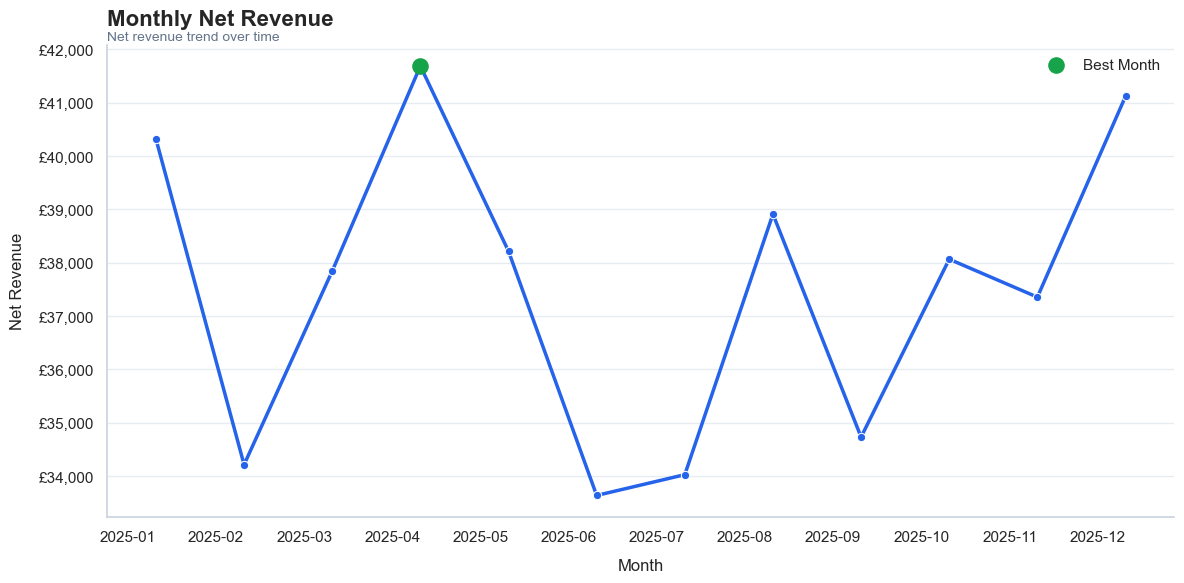

In [90]:
fig, ax = plt.subplots(figsize=(12, 6))

sns.lineplot(
    data=monthly_revenue,
    x="order_month_period",
    y="net_revenue",
    marker="o",
    linewidth=2.5,
    color=ecommerce_palette["primary"],
    ax=ax
)

best_month_idx = monthly_revenue["net_revenue"].idxmax()
best_month_row = monthly_revenue.loc[best_month_idx]

style_ax(
    ax,
    title="Monthly Net Revenue",
    subtitle="Net revenue trend over time",
    xlabel="Month",
    ylabel="Net Revenue"
)

ax.scatter(
    best_month_row["order_month_period"],
    best_month_row["net_revenue"],
    s=120,
    color=ecommerce_palette["success"],
    zorder=5,
    label="Best Month"
)

apply_currency_to_axis(
    ax,
    axis="y",
    currency_symbol="£"
)

plt.xticks(ha="right")
plt.tight_layout()

ax.legend(frameon=False)

plt.savefig(
    FIGURES_PATH / "monthly_net_revenue.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

- Net revenue fluctuated throughout 2025, with a noticeable mid-year decline followed by a recovery in the final quarter, ending December at one of the highest levels of the year.

### 6.5. Revenue per Category

In [91]:
category_performance = (
    sales
    .groupby("category", as_index=False)
    .agg(
        net_revenue=("net_revenue", "sum"),
        total_orders=("order_id", "nunique"),
        total_units=("quantity", "sum"),
        average_order_value=("net_revenue", "mean")
    )
    .sort_values(by="net_revenue", ascending=False)
)

category_performance

,category,net_revenue,total_orders,total_units,average_order_value
3,Outerwear,179762.36,1006,2355,178.690219
1,Clothing,122429.40,1523,3585,80.386999
2,Footwear,82345.32,969,2267,84.979690
0,Accessories,65567.77,1496,3511,43.828723


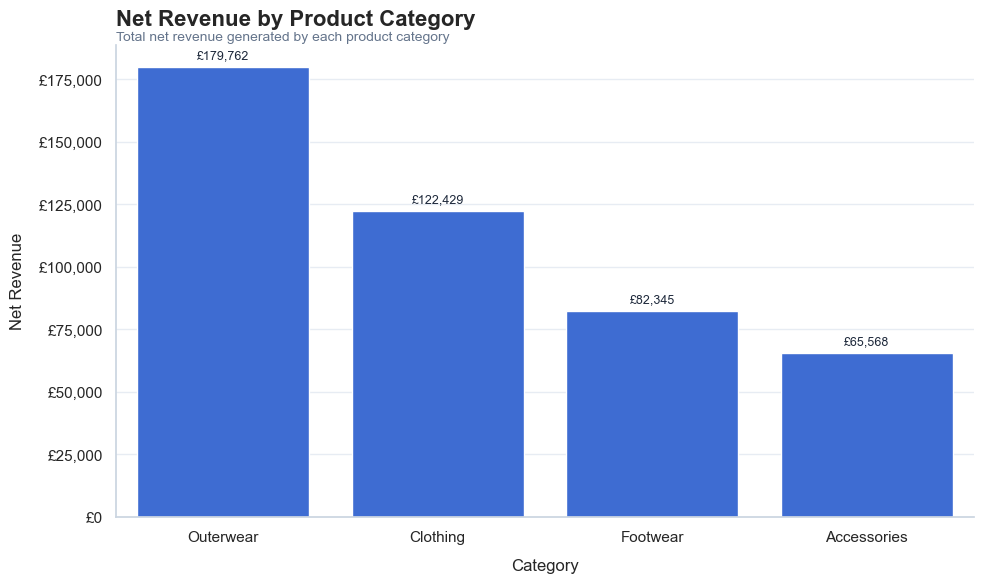

In [92]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=category_performance,
    x="category",
    y="net_revenue",
    color=ecommerce_palette["primary"],
    ax=ax
)

style_ax(
    ax,
    title="Net Revenue by Product Category",
    subtitle="Total net revenue generated by each product category",
    xlabel="Category",
    ylabel="Net Revenue"
)

apply_currency_to_axis(
    ax,
    axis="y",
    currency_symbol="£"
)

add_currency_bar_labels(
    ax,
    currency_symbol="£"
)

plt.tight_layout()

plt.savefig(
    FIGURES_PATH / "net_revenue_by_category.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

- Outerwear is the main revenue driver, while Accessories underperforms. The business should protect and expand high-performing categories while investigating whether Accessories needs better pricing, promotion, product variety, or placement.

### 6.6. Products with the Highest Revenue

In [93]:
product_revenue = (
    sales
    .groupby("product_name", as_index=False)
    .agg(
        net_revenue=("net_revenue", "sum"),
        total_units=("quantity", "sum"),
        total_orders=("order_id", "nunique"),
        average_unit_price=("unit_price", "mean")
    )
    .sort_values(by="net_revenue", ascending=False)
)

product_revenue

,product_name,net_revenue,total_units,total_orders,average_unit_price
9,Winter Jacket,96932.48,1161,486,89.990000
6,Rain Coat,82829.88,1194,520,74.990000
8,Sneakers,72545.93,1203,516,64.757442
3,Denim Jeans,57423.19,1237,530,49.990000
4,Hoodie,43949.78,1178,502,40.067689
5,Leather Belt,28077.06,1208,524,24.990000
1,Canvas Tote Bag,22128.51,1191,497,19.990000
2,Classic T-Shirt,21056.43,1170,491,19.285316
0,Baseball Cap,15362.20,1112,475,14.990000
7,Running Socks,9799.39,1064,453,9.990000


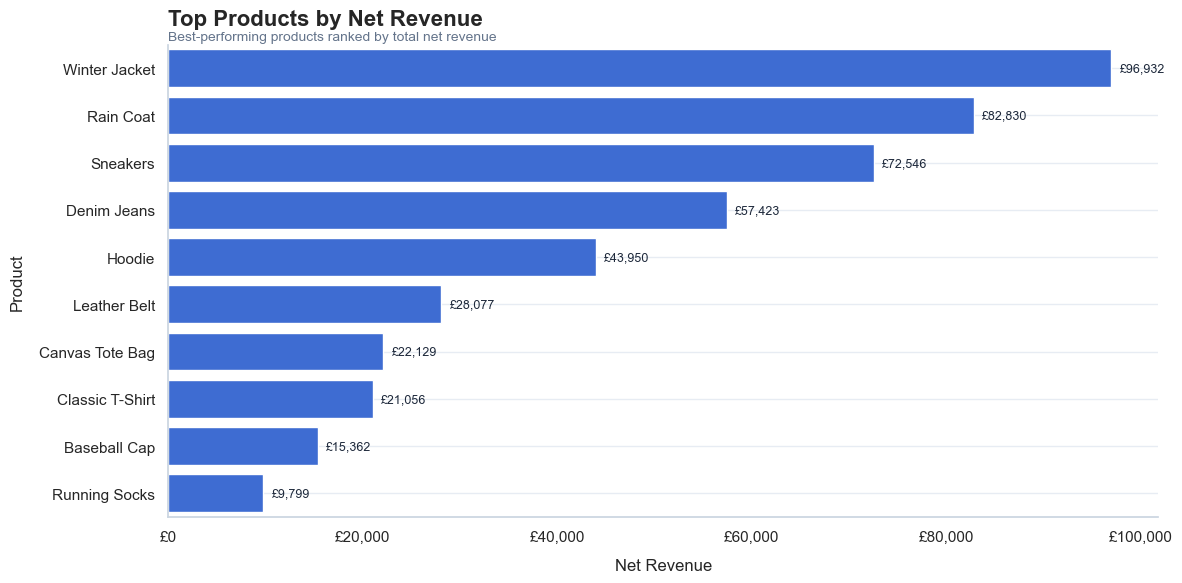

In [94]:
fig, ax = plt.subplots(figsize=(12, 6))

sns.barplot(
    data=product_revenue,
    x="net_revenue",
    y="product_name",
    color=ecommerce_palette["primary"],
    ax=ax
)

style_ax(
    ax,
    title="Top Products by Net Revenue",
    subtitle="Best-performing products ranked by total net revenue",
    xlabel="Net Revenue",
    ylabel="Product"
)

apply_currency_to_axis(
    ax,
    axis="x",
    currency_symbol="£"
)

add_currency_horizontal_bar_labels(
    ax,
    currency_symbol="£"
)

plt.tight_layout()

plt.savefig(
    FIGURES_PATH / "top_products_by_revenue.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

- Revenue is heavily concentrated in a few key products, especially Winter Jacket, Rain Coat, and Sneakers. The business should prioritize stock, pricing, and promotion for these high-performing items while reviewing whether lower-revenue products are worth keeping, bundling, or discounting.

### 6.7. Best Sellers by Quantity

In [95]:
product_units = (
    sales
    .groupby("product_name", as_index=False)
    .agg(
        total_units=("quantity", "sum"),
        net_revenue=("net_revenue", "sum"),
        average_unit_price=("unit_price", "mean")
    )
    .sort_values(by="total_units", ascending=False)
)

product_units

,product_name,total_units,net_revenue,average_unit_price
3,Denim Jeans,1237,57423.19,49.990000
5,Leather Belt,1208,28077.06,24.990000
8,Sneakers,1203,72545.93,64.757442
6,Rain Coat,1194,82829.88,74.990000
1,Canvas Tote Bag,1191,22128.51,19.990000
4,Hoodie,1178,43949.78,40.067689
2,Classic T-Shirt,1170,21056.43,19.285316
9,Winter Jacket,1161,96932.48,89.990000
0,Baseball Cap,1112,15362.20,14.990000
7,Running Socks,1064,9799.39,9.990000


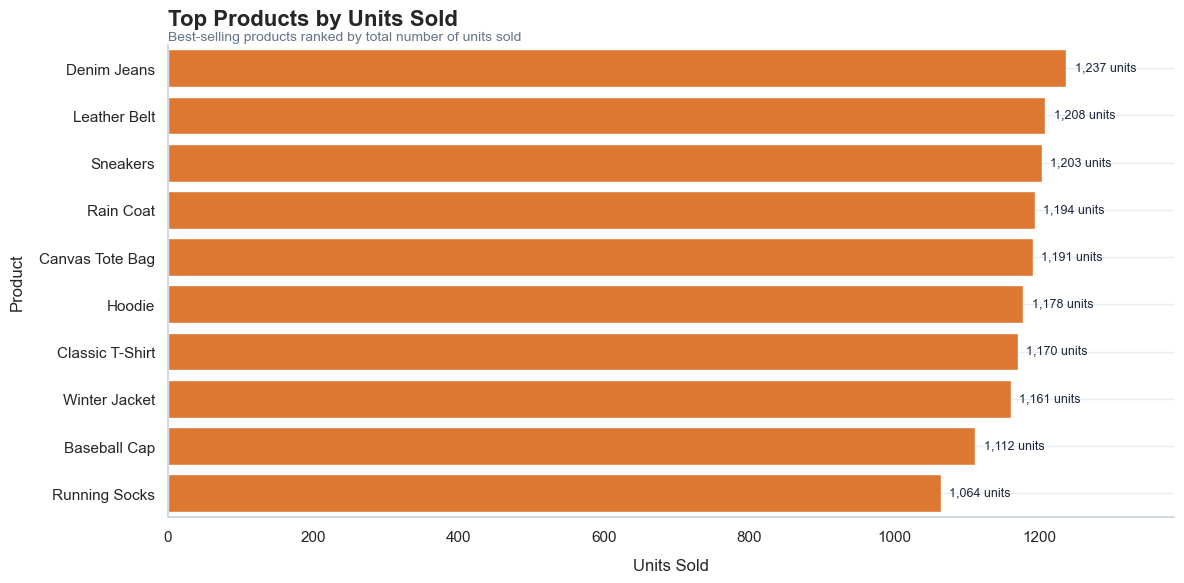

In [96]:
fig, ax = plt.subplots(figsize=(12, 6))

sns.barplot(
    data=product_units,
    x="total_units",
    y="product_name",
    color=ecommerce_palette["accent"],
    ax=ax
)

style_ax(
    ax,
    title="Top Products by Units Sold",
    subtitle="Best-selling products ranked by total number of units sold",
    xlabel="Units Sold",
    ylabel="Product"
)

ax.set_xlim(0, product_units["total_units"].max() * 1.12)

add_horizontal_bar_labels(
    ax,
    fmt="{:,.0f}",
    suffix=" units"
)

plt.tight_layout()

plt.savefig(
    FIGURES_PATH / "top_products_by_units_sold.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

- Sales volume is broadly distributed across products, with no extreme concentration. However, the comparison with revenue shows that high-volume products are not always the biggest revenue drivers, meaning pricing and product margin should be analysed next.

### 6.8. Net Revenue by Sales Channel

In [97]:
channel_performance = (
    sales
    .groupby("sales_channel", as_index=False)
    .agg(
        net_revenue=("net_revenue", "sum"),
        total_orders=("order_id", "nunique"),
        total_units=("quantity", "sum"),
        average_order_value=("net_revenue", "mean")
    )
    .sort_values(by="net_revenue", ascending=False)
)

channel_performance

,sales_channel,net_revenue,total_orders,total_units,average_order_value
2,Physical Store,199980.83,2219,5196,90.122050
1,Online Store,182475.40,2021,4723,90.289659
0,Marketplace,67648.62,754,1799,89.719655


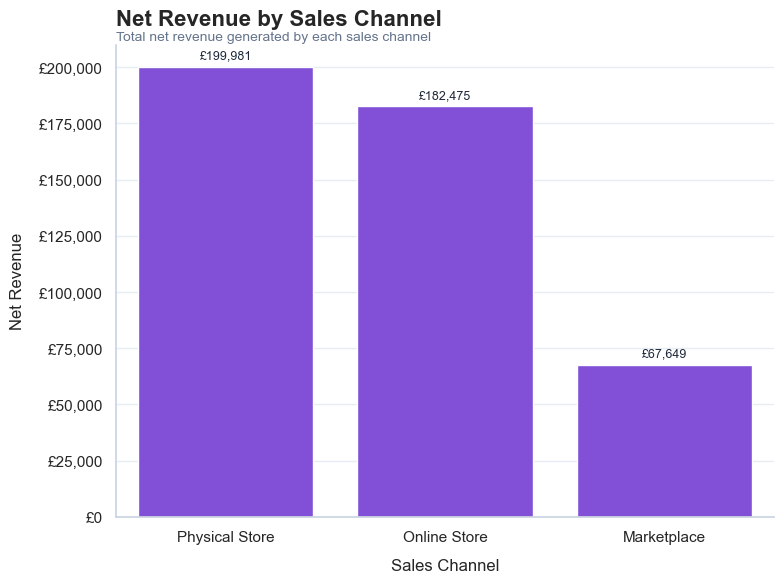

In [98]:
fig, ax = plt.subplots(figsize=(8, 6))

sns.barplot(
    data=channel_performance,
    x="sales_channel",
    y="net_revenue",
    color=ecommerce_palette["secondary"],
    ax=ax
)

style_ax(
    ax,
    title="Net Revenue by Sales Channel",
    subtitle="Total net revenue generated by each sales channel",
    xlabel="Sales Channel",
    ylabel="Net Revenue"
)

apply_currency_to_axis(
    ax,
    axis="y",
    currency_symbol="£"
)

add_currency_bar_labels(
    ax,
    currency_symbol="£"
)

plt.tight_layout()

plt.savefig(
    FIGURES_PATH / "net_revenue_by_sales_channel.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

- Physical Store and Online Store are the main revenue drivers, while Marketplace significantly underperforms. The business should protect its owned channels and investigate whether Marketplace can be improved or should remain a secondary channel.

### 6.9. Net Revenue by City

In [99]:
city_performance = (
    sales
    .groupby("city", as_index=False)
    .agg(
        net_revenue=("net_revenue", "sum"),
        total_orders=("order_id", "nunique"),
        total_units=("quantity", "sum")
    )
    .sort_values(by="net_revenue", ascending=False)
)

city_performance

,city,net_revenue,total_orders,total_units
4,Glasgow,56858.20,591,1445
5,Leeds,54210.23,606,1422
0,Birmingham,53356.03,559,1352
1,Bristol,50755.00,553,1305
2,Cardiff,50003.25,547,1280
3,Edinburgh,48748.14,536,1235
6,Liverpool,47429.98,531,1251
8,Manchester,44324.58,533,1218
7,London,43840.63,532,1190
9,Unknown,578.81,6,20


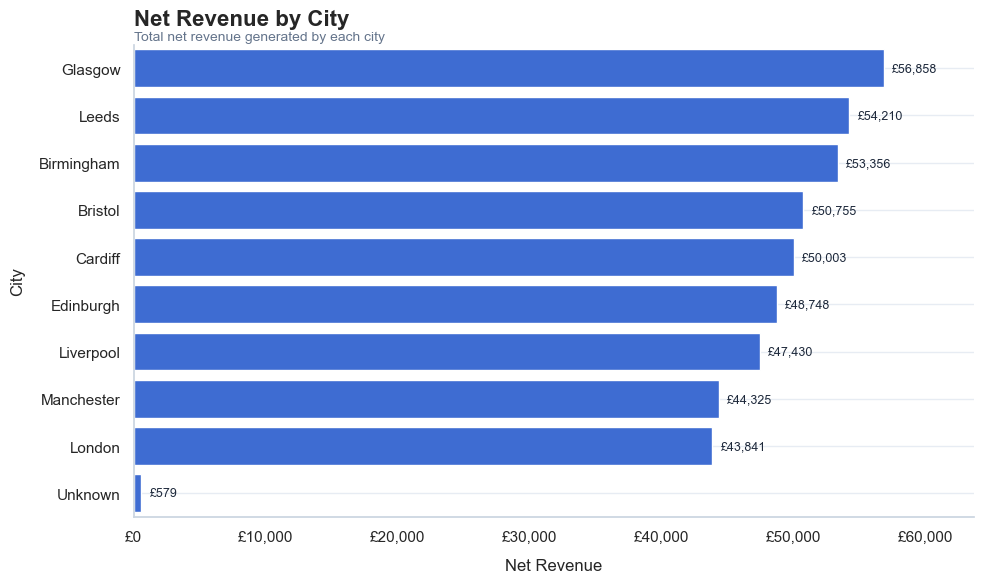

In [100]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=city_performance,
    x="net_revenue",
    y="city",
    color=ecommerce_palette["primary"],
    ax=ax
)

style_ax(
    ax,
    title="Net Revenue by City",
    subtitle="Total net revenue generated by each city",
    xlabel="Net Revenue",
    ylabel="City"
)

apply_currency_to_axis(
    ax,
    axis="x",
    currency_symbol="£"
)

ax.set_xlim(0, city_performance["net_revenue"].max() * 1.12)

add_currency_horizontal_bar_labels(
    ax,
    currency_symbol="£"
)

plt.tight_layout()

plt.savefig(
    FIGURES_PATH / "net_revenue_by_city.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

- Revenue is fairly well distributed across cities, with Glasgow, Leeds, and Birmingham leading. London underperforms compared with other major cities, which may justify a closer review of customer base, product mix, marketing reach, or store/channel presence in that location.

### 6.10. Payment Methods

In [101]:
payment_performance = (
    sales
    .groupby("payment_method", as_index=False)
    .agg(
        total_orders=("order_id", "nunique"),
        net_revenue=("net_revenue", "sum")
    )
    .sort_values(by="total_orders", ascending=False)
)

payment_performance

,payment_method,total_orders,net_revenue
1,Cash,1056,97749.59
0,Bank Transfer,998,87485.52
3,Debit Card,995,88505.79
4,PayPal,987,90881.30
2,Credit Card,958,85482.65


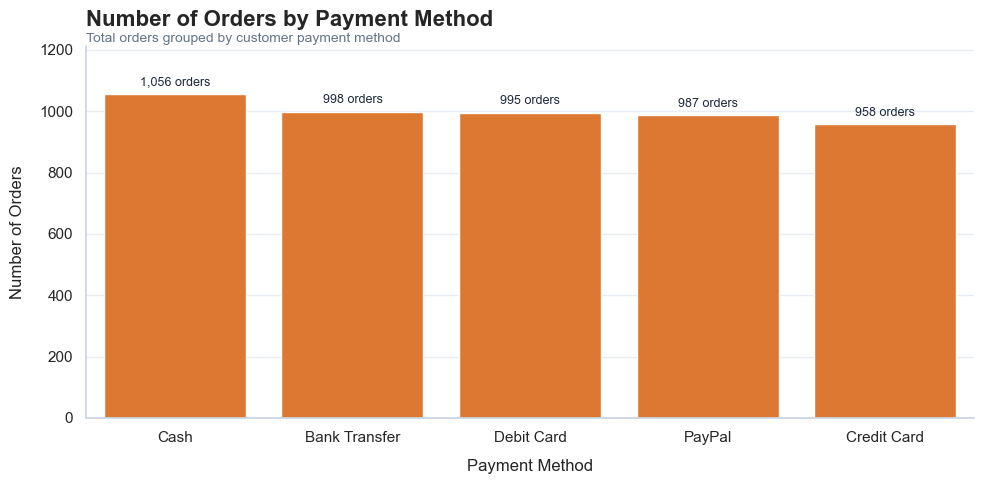

In [102]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.barplot(
    data=payment_performance,
    x="payment_method",
    y="total_orders",
    color=ecommerce_palette["accent"],
    ax=ax
)

style_ax(
    ax,
    title="Number of Orders by Payment Method",
    subtitle="Total orders grouped by customer payment method",
    xlabel="Payment Method",
    ylabel="Number of Orders"
)

ax.set_ylim(0, payment_performance["total_orders"].max() * 1.15)

add_bar_labels(
    ax,
    fmt="{:,.0f}",
    suffix=" orders"
)

plt.tight_layout()

plt.savefig(
    FIGURES_PATH / "orders_by_payment_method.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

- Orders are evenly distributed across payment methods, with Cash slightly leading. There is no clear payment bottleneck, but Credit Card usage could be reviewed to check whether fees, checkout experience, or customer preference are affecting adoption.

### 6.11. Discount Analysis

In [103]:
discount_summary = sales["discount_percent"].describe()

discount_summary

count    4994.000000
mean        7.196636
std         7.483916
min         0.000000
25%         0.000000
50%         5.000000
75%        15.000000
max        20.000000
Name: discount_percent, dtype: float64

In [104]:
discount_distribution = (
    sales
    .groupby("discount_percent", as_index=False)
    .agg(
        total_orders=("order_id", "nunique"),
        net_revenue=("net_revenue", "sum"),
        total_units=("quantity", "sum")
    )
    .sort_values(by="discount_percent")
)

discount_distribution

,discount_percent,total_orders,net_revenue,total_units
0,0.0,2112,202929.25,4875
1,5.0,723,68470.89,1746
2,10.0,731,63943.69,1719
3,15.0,709,58994.58,1674
4,20.0,719,55766.44,1704


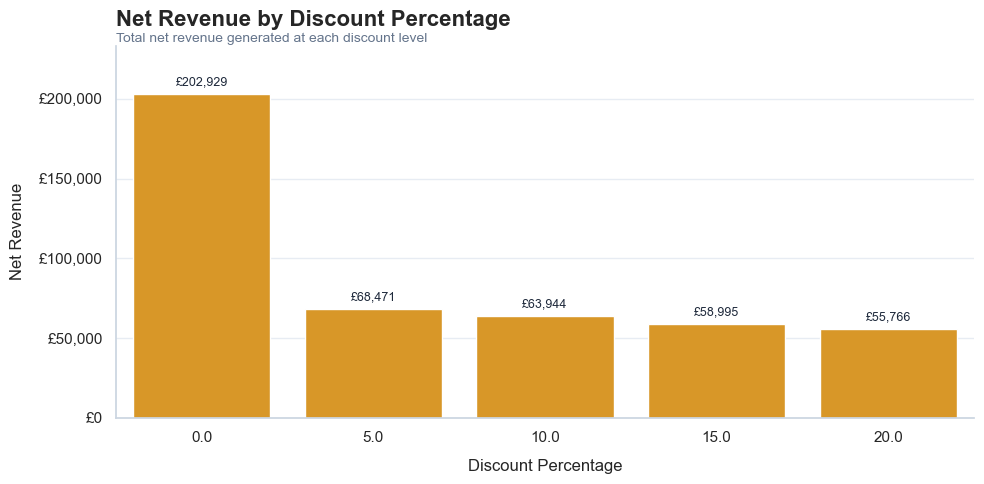

In [105]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.barplot(
    data=discount_distribution,
    x="discount_percent",
    y="net_revenue",
    color=ecommerce_palette["warning"],
    ax=ax
)

style_ax(
    ax,
    title="Net Revenue by Discount Percentage",
    subtitle="Total net revenue generated at each discount level",
    xlabel="Discount Percentage",
    ylabel="Net Revenue"
)

apply_currency_to_axis(
    ax,
    axis="y",
    currency_symbol="£"
)

ax.set_ylim(0, discount_distribution["net_revenue"].max() * 1.15)

add_currency_bar_labels(
    ax,
    currency_symbol="£"
)

plt.tight_layout()

plt.savefig(
    FIGURES_PATH / "net_revenue_by_discount_percentage.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

- Most net revenue comes from full-price sales. Discounted orders contribute less, and higher discounts do not clearly improve revenue, so the business should review whether discounts are necessary, especially above 5%.

### 6.11. Gross Revenue, Discounts, and Net Revenue per Month

In [106]:
monthly_revenue_comparison = monthly_revenue[
    [
        "order_month_period",
        "gross_revenue",
        "total_discount",
        "net_revenue"
    ]
]

monthly_revenue_comparison

,order_month_period,gross_revenue,total_discount,net_revenue
0,2025-01,43371.88,3053.52,40318.35
1,2025-02,36664.40,2452.89,34211.49
2,2025-03,40754.00,2912.12,37841.91
3,2025-04,45155.76,3469.94,41685.87
4,2025-05,41089.78,2875.70,38214.12
5,2025-06,36261.28,2626.75,33634.55
6,2025-07,36677.02,2653.02,34024.02
7,2025-08,41813.67,2903.37,38910.33
8,2025-09,37475.73,2746.64,34729.10
9,2025-10,41329.55,3265.34,38064.21


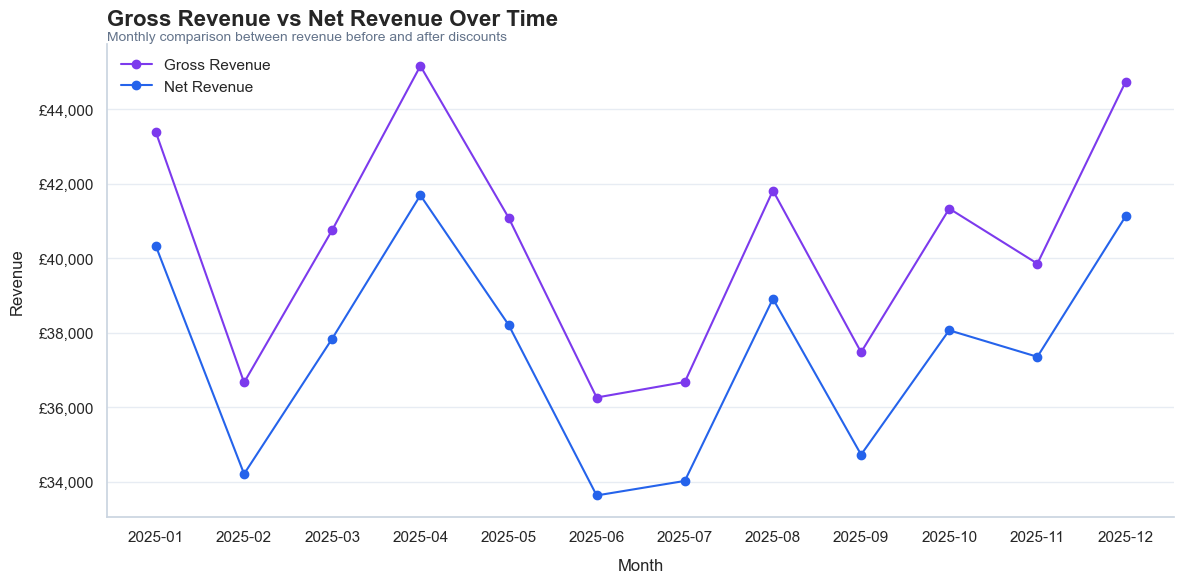

In [107]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    monthly_revenue_comparison["order_month_period"],
    monthly_revenue_comparison["gross_revenue"],
    marker="o",
    label="Gross Revenue",
    color=ecommerce_palette["secondary"]
)

ax.plot(
    monthly_revenue_comparison["order_month_period"],
    monthly_revenue_comparison["net_revenue"],
    marker="o",
    label="Net Revenue",
    color=ecommerce_palette["primary"]
)

style_ax(
    ax,
    title="Gross Revenue vs Net Revenue Over Time",
    subtitle="Monthly comparison between revenue before and after discounts",
    xlabel="Month",
    ylabel="Revenue"
)

apply_currency_to_axis(
    ax,
    axis="y",
    currency_symbol="£"
)

ax.legend(
    frameon=False,
    loc="best"
)

plt.tight_layout()

plt.savefig(
    FIGURES_PATH / "gross_vs_net_revenue_over_time.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

- Gross and net revenue move together throughout the year, with a clear mid-year decline and year-end recovery. Discounts reduce monthly revenue, but they do not appear to fundamentally change the sales trend.

### 6.12. Create a Summary Ranking for Analysis

In [108]:
eda_summary = {
    "total_net_revenue": total_revenue,
    "total_orders": total_orders,
    "total_units_sold": total_units_sold,
    "average_order_value": average_order_value,
    "best_month_by_revenue": monthly_revenue.loc[
        monthly_revenue["net_revenue"].idxmax(), 
        "order_month_period"
    ],
    "best_category_by_revenue": category_performance.iloc[0]["category"],
    "best_product_by_revenue": product_revenue.iloc[0]["product_name"],
    "best_channel_by_revenue": channel_performance.iloc[0]["sales_channel"],
    "best_city_by_revenue": city_performance.iloc[0]["city"],
}

eda_summary

{'total_net_revenue': np.float64(450104.85000000003),
 'total_orders': 4994,
 'total_units_sold': np.int64(11718),
 'average_order_value': np.float64(90.12912494993994),
 'best_month_by_revenue': '2025-04',
 'best_category_by_revenue': 'Outerwear',
 'best_product_by_revenue': 'Winter Jacket',
 'best_channel_by_revenue': 'Physical Store',
 'best_city_by_revenue': 'Glasgow'}

In [109]:
eda_summary_df = pd.DataFrame({
    "metric": [
        "Total Net Revenue",
        "Total Orders",
        "Total Units Sold",
        "Average Order Value",
        "Best Month by Revenue",
        "Best Category by Revenue",
        "Best Product by Revenue",
        "Best Channel by Revenue",
        "Best City by Revenue"
    ],
    "value": [
        format_currency(eda_summary["total_net_revenue"]),
        f"{eda_summary['total_orders']:,}",
        f"{eda_summary['total_units_sold']:,}",
        format_currency(eda_summary["average_order_value"]),
        eda_summary["best_month_by_revenue"],
        eda_summary["best_category_by_revenue"],
        eda_summary["best_product_by_revenue"],
        eda_summary["best_channel_by_revenue"],
        eda_summary["best_city_by_revenue"],
    ]
})

eda_summary_df

,metric,value
0,Total Net Revenue,"£450,105"
1,Total Orders,"4,994"
2,Total Units Sold,"11,718"
3,Average Order Value,£90
4,Best Month by Revenue,2025-04
5,Best Category by Revenue,Outerwear
6,Best Product by Revenue,Winter Jacket
7,Best Channel by Revenue,Physical Store
8,Best City by Revenue,Glasgow


In [110]:
eda_summary_path = PROJECT_ROOT / "reports" / "eda_summary.csv"

eda_summary_df.to_csv(eda_summary_path, index=False)

print(f"EDA summary saved at: {eda_summary_path}")

EDA summary saved at: C:\Users\Joalyson Lima\OneDrive\Área de Trabalho\small-business-sales-analysis\reports\eda_summary.csv


### 6.13. Save Main EDA Tables

In [111]:
category_performance.to_csv(
    PROJECT_ROOT / "reports" / "category_performance.csv",
    index=False
)

product_revenue.to_csv(
    PROJECT_ROOT / "reports" / "product_revenue.csv",
    index=False
)

channel_performance.to_csv(
    PROJECT_ROOT / "reports" / "channel_performance.csv",
    index=False
)

monthly_revenue.to_csv(
    PROJECT_ROOT / "reports" / "monthly_revenue.csv",
    index=False
)

city_performance.to_csv(
    PROJECT_ROOT / "reports" / "city_performance.csv",
    index=False
)

## 7. Key Business Metrics

### 7.1. General Business Metrics

In [112]:
total_gross_revenue = sales["gross_revenue"].sum()
total_net_revenue = sales["net_revenue"].sum()
total_discount = sales["discount_amount"].sum()

total_orders = sales["order_id"].nunique()
total_units_sold = sales["quantity"].sum()
total_customers = sales["customer_id"].nunique()

average_order_value = total_net_revenue / total_orders
average_units_per_order = total_units_sold / total_orders
revenue_per_customer = total_net_revenue / total_customers

discount_rate = total_discount / total_gross_revenue * 100
average_discount_percent = sales["discount_percent"].mean()

overall_kpis = pd.DataFrame({
    "metric": [
        "Gross Revenue",
        "Net Revenue",
        "Total Discount",
        "Discount Rate",
        "Total Orders",
        "Total Units Sold",
        "Total Customers",
        "Average Order Value",
        "Average Units per Order",
        "Revenue per Customer",
        "Average Discount Percentage"
    ],
    "value": [
        format_currency(total_gross_revenue),
        format_currency(total_net_revenue),
        format_currency(total_discount),
        format_percentage(discount_rate),
        f"{total_orders:,}",
        f"{total_units_sold:,}",
        f"{total_customers:,}",
        format_currency(average_order_value),
        f"{average_units_per_order:.2f}",
        format_currency(revenue_per_customer),
        format_percentage(average_discount_percent)
    ],
    "business_meaning": [
        "Total sales value before discounts.",
        "Actual sales value after discounts.",
        "Total amount deducted through discounts.",
        "Share of gross revenue lost to discounts.",
        "Number of unique orders.",
        "Total number of items sold.",
        "Number of unique customers.",
        "Average revenue generated per order.",
        "Average number of items sold per order.",
        "Average revenue generated per customer.",
        "Average discount percentage applied to transactions."
    ]
})

overall_kpis

,metric,value,business_meaning
0,Gross Revenue,"£485,170",Total sales value before discounts.
1,Net Revenue,"£450,105",Actual sales value after discounts.
2,Total Discount,"£35,065",Total amount deducted through discounts.
3,Discount Rate,7.23%,Share of gross revenue lost to discounts.
4,Total Orders,"4,994",Number of unique orders.
5,Total Units Sold,"11,718",Total number of items sold.
6,Total Customers,150,Number of unique customers.
7,Average Order Value,£90,Average revenue generated per order.
8,Average Units per Order,2.35,Average number of items sold per order.
9,Revenue per Customer,"£3,001",Average revenue generated per customer.


- The overall KPIs summarize the business performance at a high level. Net revenue is treated as the main revenue metric because it reflects sales after discounts.

### 7.2. Monthly Metrics

In [113]:
monthly_metrics = (
    sales
    .groupby("order_month_period", as_index=False)
    .agg(
        gross_revenue=("gross_revenue", "sum"),
        net_revenue=("net_revenue", "sum"),
        total_discount=("discount_amount", "sum"),
        total_orders=("order_id", "nunique"),
        total_units=("quantity", "sum"),
        total_customers=("customer_id", "nunique")
    )
)

monthly_metrics["average_order_value"] = (
    monthly_metrics["net_revenue"] / monthly_metrics["total_orders"]
).round(2)

monthly_metrics["discount_rate"] = (
    monthly_metrics["total_discount"] / monthly_metrics["gross_revenue"] * 100
).round(2)

monthly_metrics["monthly_revenue_growth_pct"] = (
    monthly_metrics["net_revenue"].pct_change() * 100
).round(2)

monthly_metrics

,order_month_period,gross_revenue,net_revenue,total_discount,total_orders,total_units,total_customers,average_order_value,discount_rate,monthly_revenue_growth_pct
0,2025-01,43371.88,40318.35,3053.52,436,1012,136,92.47,7.04,NaN
1,2025-02,36664.40,34211.49,2452.89,365,860,142,93.73,6.69,-15.15
2,2025-03,40754.00,37841.91,2912.12,428,1000,145,88.42,7.15,10.61
3,2025-04,45155.76,41685.87,3469.94,431,1024,141,96.72,7.68,10.16
4,2025-05,41089.78,38214.12,2875.70,425,1022,136,89.92,7.00,-8.33
5,2025-06,36261.28,33634.55,2626.75,384,872,134,87.59,7.24,-11.98
6,2025-07,36677.02,34024.02,2653.02,392,898,141,86.80,7.23,1.16
7,2025-08,41813.67,38910.33,2903.37,436,1033,142,89.24,6.94,14.36
8,2025-09,37475.73,34729.10,2746.64,389,927,143,89.28,7.33,-10.75
9,2025-10,41329.55,38064.21,3265.34,457,1045,145,83.29,7.90,9.60


In [114]:
best_month = monthly_metrics.loc[
    monthly_metrics["net_revenue"].idxmax()
]

worst_month = monthly_metrics.loc[
    monthly_metrics["net_revenue"].idxmin()
]

print("Best month by revenue:")
print(best_month)

print("\nWorst month by revenue:")
print(worst_month)

Best month by revenue:
order_month_period             2025-04
gross_revenue                 45155.76
net_revenue                   41685.87
total_discount                 3469.94
total_orders                       431
total_units                       1024
total_customers                    141
average_order_value              96.72
discount_rate                     7.68
monthly_revenue_growth_pct       10.16
Name: 3, dtype: object

Worst month by revenue:
order_month_period             2025-06
gross_revenue                 36261.28
net_revenue                   33634.55
total_discount                 2626.75
total_orders                       384
total_units                        872
total_customers                    134
average_order_value              87.59
discount_rate                     7.24
monthly_revenue_growth_pct      -11.98
Name: 5, dtype: object


- Monthly metrics help identify seasonal patterns, stronger sales periods, weaker sales periods, and month-over-month revenue changes.

### 7.3. Metrics by Category

In [115]:
category_metrics = (
    sales
    .groupby("category", as_index=False)
    .agg(
        net_revenue=("net_revenue", "sum"),
        gross_revenue=("gross_revenue", "sum"),
        total_discount=("discount_amount", "sum"),
        total_orders=("order_id", "nunique"),
        total_units=("quantity", "sum")
    )
)

category_metrics["revenue_share_pct"] = (
    category_metrics["net_revenue"] / total_net_revenue * 100
).round(2)

category_metrics["average_order_value"] = (
    category_metrics["net_revenue"] / category_metrics["total_orders"]
).round(2)

category_metrics["discount_rate"] = (
    category_metrics["total_discount"] / category_metrics["gross_revenue"] * 100
).round(2)

category_metrics = category_metrics.sort_values(
    by="net_revenue", 
    ascending=False
)

category_metrics

,category,net_revenue,gross_revenue,total_discount,total_orders,total_units,revenue_share_pct,average_order_value,discount_rate
3,Outerwear,179762.36,194016.45,14254.21,1006,2355,39.94,178.69,7.35
1,Clothing,122429.40,131891.15,9461.87,1523,3585,27.20,80.39,7.17
2,Footwear,82345.32,88597.33,6252.08,969,2267,18.29,84.98,7.06
0,Accessories,65567.77,70664.89,5097.03,1496,3511,14.57,43.83,7.21


- Category-level metrics show which product groups contribute most to revenue and sales volume. Revenue share helps identify business dependence on specific categories.

### 7.4. Metrics by Sales Channel

In [116]:
channel_metrics = (
    sales
    .groupby("sales_channel", as_index=False)
    .agg(
        net_revenue=("net_revenue", "sum"),
        gross_revenue=("gross_revenue", "sum"),
        total_discount=("discount_amount", "sum"),
        total_orders=("order_id", "nunique"),
        total_units=("quantity", "sum")
    )
)

channel_metrics["revenue_share_pct"] = (
    channel_metrics["net_revenue"] / total_net_revenue * 100
).round(2)

channel_metrics["average_order_value"] = (
    channel_metrics["net_revenue"] / channel_metrics["total_orders"]
).round(2)

channel_metrics["discount_rate"] = (
    channel_metrics["total_discount"] / channel_metrics["gross_revenue"] * 100
).round(2)

channel_metrics = channel_metrics.sort_values(
    by="net_revenue", 
    ascending=False
)

channel_metrics

,sales_channel,net_revenue,gross_revenue,total_discount,total_orders,total_units,revenue_share_pct,average_order_value,discount_rate
2,Physical Store,199980.83,215814.04,15833.30,2219,5196,44.43,90.12,7.34
1,Online Store,182475.40,196835.77,14360.50,2021,4723,40.54,90.29,7.30
0,Marketplace,67648.62,72520.01,4871.39,754,1799,15.03,89.72,6.72


- Sales channel metrics help compare performance across physical store, online store, and marketplace. This can support decisions about marketing focus, channel investment, and sales strategy.

### 7.5. Metrics by Product

In [117]:
product_metrics = (
    sales
    .groupby(["product_name", "category"], as_index=False)
    .agg(
        net_revenue=("net_revenue", "sum"),
        gross_revenue=("gross_revenue", "sum"),
        total_discount=("discount_amount", "sum"),
        total_orders=("order_id", "nunique"),
        total_units=("quantity", "sum"),
        average_unit_price=("unit_price", "mean")
    )
)

product_metrics["revenue_share_pct"] = (
    product_metrics["net_revenue"] / total_net_revenue * 100
).round(2)

product_metrics["average_order_value"] = (
    product_metrics["net_revenue"] / product_metrics["total_orders"]
).round(2)

product_metrics["discount_rate"] = (
    product_metrics["total_discount"] / product_metrics["gross_revenue"] * 100
).round(2)

product_metrics = product_metrics.sort_values(
    by="net_revenue", 
    ascending=False
)

product_metrics["cumulative_revenue_share_pct"] = (
    product_metrics["revenue_share_pct"].cumsum()
).round(2)

product_metrics

,product_name,category,net_revenue,gross_revenue,total_discount,total_orders,total_units,average_unit_price,revenue_share_pct,average_order_value,discount_rate,cumulative_revenue_share_pct
9,Winter Jacket,Outerwear,96932.48,104478.39,7546.03,486,1161,89.990000,21.54,199.45,7.22,21.54
6,Rain Coat,Outerwear,82829.88,89538.06,6708.18,520,1194,74.990000,18.40,159.29,7.49,39.94
8,Sneakers,Footwear,72545.93,77967.97,5422.04,516,1203,64.757442,16.12,140.59,6.95,56.06
3,Denim Jeans,Clothing,57423.19,61837.63,4414.55,530,1237,49.990000,12.76,108.35,7.14,68.82
4,Hoodie,Clothing,43949.78,47382.22,3432.55,502,1178,40.067689,9.76,87.55,7.24,78.58
5,Leather Belt,Accessories,28077.06,30187.92,2110.86,524,1208,24.990000,6.24,53.58,6.99,84.82
1,Canvas Tote Bag,Accessories,22128.51,23808.09,1679.45,497,1191,19.990000,4.92,44.52,7.05,89.74
2,Classic T-Shirt,Clothing,21056.43,22671.30,1614.77,491,1170,19.285316,4.68,42.88,7.12,94.42
0,Baseball Cap,Accessories,15362.20,16668.88,1306.72,475,1112,14.990000,3.41,32.34,7.84,97.83
7,Running Socks,Footwear,9799.39,10629.36,830.04,453,1064,9.990000,2.18,21.63,7.81,100.01


- Product-level metrics help identify the strongest revenue drivers, high-volume products, and the concentration of revenue among top products.

### 7.6. Contribution of Main Products

In [118]:
top_3_products_revenue = product_metrics.head(3)["net_revenue"].sum()
top_5_products_revenue = product_metrics.head(5)["net_revenue"].sum()

top_3_revenue_share = top_3_products_revenue / total_net_revenue * 100
top_5_revenue_share = top_5_products_revenue / total_net_revenue * 100

top_products_contribution = pd.DataFrame({
    "metric": [
        "Top 3 Products Revenue",
        "Top 3 Products Revenue Share",
        "Top 5 Products Revenue",
        "Top 5 Products Revenue Share"
    ],
    "value": [
        format_currency(top_3_products_revenue),
        format_percentage(top_3_revenue_share),
        format_currency(top_5_products_revenue),
        format_percentage(top_5_revenue_share)
    ]
})

top_products_contribution

,metric,value
0,Top 3 Products Revenue,"£252,308"
1,Top 3 Products Revenue Share,56.06%
2,Top 5 Products Revenue,"£353,681"
3,Top 5 Products Revenue Share,78.58%


- Top product contribution helps evaluate whether revenue is concentrated in a small number of products. High concentration can be positive if those products are strong performers, but it can also create dependency risk.

### 7.7. Discount Metrics

In [119]:
sales["has_discount"] = sales["discount_percent"] > 0

In [120]:
processed_file_path = PROJECT_ROOT / "data" / "processed" / "small_business_sales_clean.csv"
sales.to_csv(processed_file_path, index=False)

In [121]:
discount_metrics = (
    sales
    .groupby("has_discount", as_index=False)
    .agg(
        net_revenue=("net_revenue", "sum"),
        gross_revenue=("gross_revenue", "sum"),
        total_discount=("discount_amount", "sum"),
        total_orders=("order_id", "nunique"),
        total_units=("quantity", "sum"),
        average_discount_percent=("discount_percent", "mean")
    )
)

discount_metrics["revenue_share_pct"] = (
    discount_metrics["net_revenue"] / total_net_revenue * 100
).round(2)

discount_metrics["average_order_value"] = (
    discount_metrics["net_revenue"] / discount_metrics["total_orders"]
).round(2)

discount_metrics["discount_rate"] = (
    discount_metrics["total_discount"] / discount_metrics["gross_revenue"] * 100
).round(2)

discount_metrics["discount_group"] = discount_metrics["has_discount"].map({
    True: "Discounted Orders",
    False: "Non-Discounted Orders"
})

discount_metrics = discount_metrics[
    [
        "discount_group",
        "net_revenue",
        "gross_revenue",
        "total_discount",
        "total_orders",
        "total_units",
        "average_discount_percent",
        "revenue_share_pct",
        "average_order_value",
        "discount_rate"
    ]
]

discount_metrics

,discount_group,net_revenue,gross_revenue,total_discount,total_orders,total_units,average_discount_percent,revenue_share_pct,average_order_value,discount_rate
0,Non-Discounted Orders,202929.25,202929.25,0.00,2112,4875,0.000000,45.08,96.08,0.00
1,Discounted Orders,247175.60,282240.57,35065.19,2882,6843,12.470507,54.92,85.77,12.42


- Discount metrics compare discounted and non-discounted transactions. This analysis shows how much revenue comes from discounted orders, but it does not prove whether discounts caused higher demand.

### 7.8. Metrics by Payment Method

In [122]:
payment_metrics = (
    sales
    .groupby("payment_method", as_index=False)
    .agg(
        net_revenue=("net_revenue", "sum"),
        total_orders=("order_id", "nunique"),
        total_units=("quantity", "sum")
    )
)

payment_metrics["revenue_share_pct"] = (
    payment_metrics["net_revenue"] / total_net_revenue * 100
).round(2)

payment_metrics["order_share_pct"] = (
    payment_metrics["total_orders"] / total_orders * 100
).round(2)

payment_metrics = payment_metrics.sort_values(
    by="total_orders", 
    ascending=False
)

payment_metrics

,payment_method,net_revenue,total_orders,total_units,revenue_share_pct,order_share_pct
1,Cash,97749.59,1056,2463,21.72,21.15
0,Bank Transfer,87485.52,998,2321,19.44,19.98
3,Debit Card,88505.79,995,2323,19.66,19.92
4,PayPal,90881.30,987,2389,20.19,19.76
2,Credit Card,85482.65,958,2222,18.99,19.18


- Payment method metrics help identify customer payment preferences and can support decisions about checkout options and payment processing priorities.

### 7.9. Metrics by City

In [123]:
city_metrics = (
    sales
    .groupby("city", as_index=False)
    .agg(
        net_revenue=("net_revenue", "sum"),
        total_orders=("order_id", "nunique"),
        total_units=("quantity", "sum"),
        total_customers=("customer_id", "nunique")
    )
)

city_metrics["revenue_share_pct"] = (
    city_metrics["net_revenue"] / total_net_revenue * 100
).round(2)

city_metrics["average_order_value"] = (
    city_metrics["net_revenue"] / city_metrics["total_orders"]
).round(2)

city_metrics = city_metrics.sort_values(
    by="net_revenue", 
    ascending=False
)

city_metrics

,city,net_revenue,total_orders,total_units,total_customers,revenue_share_pct,average_order_value
4,Glasgow,56858.20,591,1445,147,12.63,96.21
5,Leeds,54210.23,606,1422,145,12.04,89.46
0,Birmingham,53356.03,559,1352,145,11.85,95.45
1,Bristol,50755.00,553,1305,141,11.28,91.78
2,Cardiff,50003.25,547,1280,145,11.11,91.41
3,Edinburgh,48748.14,536,1235,143,10.83,90.95
6,Liverpool,47429.98,531,1251,143,10.54,89.32
8,Manchester,44324.58,533,1218,148,9.85,83.16
7,London,43840.63,532,1190,147,9.74,82.41
9,Unknown,578.81,6,20,6,0.13,96.47


- City-level metrics help identify the strongest customer locations and can support local marketing, delivery planning, and regional sales decisions.

### 7.10. Final Executive Table

In [124]:
best_category = category_metrics.iloc[0]
best_channel = channel_metrics.iloc[0]
best_product = product_metrics.iloc[0]
best_city = city_metrics.iloc[0]

executive_metrics = pd.DataFrame({
    "metric": [
        "Total Net Revenue",
        "Total Orders",
        "Total Units Sold",
        "Average Order Value",
        "Total Discount",
        "Overall Discount Rate",
        "Best Month by Revenue",
        "Worst Month by Revenue",
        "Top Category",
        "Top Category Revenue Share",
        "Top Product",
        "Top Product Revenue Share",
        "Top Sales Channel",
        "Top Sales Channel Revenue Share",
        "Top City",
        "Top City Revenue Share",
        "Top 5 Products Revenue Share"
    ],
    "value": [
        format_currency(total_net_revenue),
        f"{total_orders:,}",
        f"{total_units_sold:,}",
        format_currency(average_order_value),
        format_currency(total_discount),
        format_percentage(discount_rate),
        best_month["order_month_period"],
        worst_month["order_month_period"],
        best_category["category"],
        format_percentage(best_category["revenue_share_pct"]),
        best_product["product_name"],
        format_percentage(best_product["revenue_share_pct"]),
        best_channel["sales_channel"],
        format_percentage(best_channel["revenue_share_pct"]),
        best_city["city"],
        format_percentage(best_city["revenue_share_pct"]),
        format_percentage(top_5_revenue_share)
    ]
})

executive_metrics

,metric,value
0,Total Net Revenue,"£450,105"
1,Total Orders,"4,994"
2,Total Units Sold,"11,718"
3,Average Order Value,£90
4,Total Discount,"£35,065"
5,Overall Discount Rate,7.23%
6,Best Month by Revenue,2025-04
7,Worst Month by Revenue,2025-06
8,Top Category,Outerwear
9,Top Category Revenue Share,39.94%


### 7.11. Saving the KPIs

In [125]:
overall_kpis.to_csv(
    PROJECT_ROOT / "reports" / "overall_kpis.csv",
    index=False
)

monthly_metrics.to_csv(
    PROJECT_ROOT / "reports" / "monthly_business_metrics.csv",
    index=False
)

category_metrics.to_csv(
    PROJECT_ROOT / "reports" / "category_business_metrics.csv",
    index=False
)

channel_metrics.to_csv(
    PROJECT_ROOT / "reports" / "channel_business_metrics.csv",
    index=False
)

product_metrics.to_csv(
    PROJECT_ROOT / "reports" / "product_business_metrics.csv",
    index=False
)

discount_metrics.to_csv(
    PROJECT_ROOT / "reports" / "discount_business_metrics.csv",
    index=False
)

payment_metrics.to_csv(
    PROJECT_ROOT / "reports" / "payment_business_metrics.csv",
    index=False
)

city_metrics.to_csv(
    PROJECT_ROOT / "reports" / "city_business_metrics.csv",
    index=False
)

executive_metrics.to_csv(
    PROJECT_ROOT / "reports" / "executive_metrics_summary.csv",
    index=False
)

print("Business metrics saved successfully.")

Business metrics saved successfully.


## 8. Business Insights and Recommendations

### 8.1. Main Results

In [126]:
top_category = category_metrics.iloc[0]
top_channel = channel_metrics.iloc[0]
top_product = product_metrics.iloc[0]
top_city = city_metrics.iloc[0]

top_payment_method = payment_metrics.iloc[0]

discounted_orders = discount_metrics[
    discount_metrics["discount_group"] == "Discounted Orders"
].iloc[0]

non_discounted_orders = discount_metrics[
    discount_metrics["discount_group"] == "Non-Discounted Orders"
].iloc[0]

top_3_products_share = product_metrics.head(3)["revenue_share_pct"].sum()

summary_values = {
    "total_net_revenue": format_currency(total_net_revenue),
    "total_orders": f"{total_orders:,}",
    "average_order_value": format_currency(average_order_value),
    "total_discount": format_currency(total_discount),
    "discount_rate": format_percentage(discount_rate),
    "best_month": best_month["order_month_period"],
    "best_month_revenue": format_currency(best_month["net_revenue"]),
    "worst_month": worst_month["order_month_period"],
    "worst_month_revenue": format_currency(worst_month["net_revenue"]),
    "top_category": top_category["category"],
    "top_category_share": format_percentage(top_category["revenue_share_pct"]),
    "top_product": top_product["product_name"],
    "top_product_share": format_percentage(top_product["revenue_share_pct"]),
    "top_channel": top_channel["sales_channel"],
    "top_channel_share": format_percentage(top_channel["revenue_share_pct"]),
    "top_city": top_city["city"],
    "top_city_share": format_percentage(top_city["revenue_share_pct"]),
    "top_5_products_share": format_percentage(top_5_revenue_share),
    "discounted_orders_share": format_percentage(discounted_orders["revenue_share_pct"]),
    "discounted_aov": format_currency(discounted_orders["average_order_value"]),
    "non_discounted_aov": format_currency(non_discounted_orders["average_order_value"]),
    "top_payment_method": top_payment_method["payment_method"],
    "top_payment_order_share": format_percentage(top_payment_method["order_share_pct"])
}

summary_values

{'total_net_revenue': '£450,105',
 'total_orders': '4,994',
 'average_order_value': '£90',
 'total_discount': '£35,065',
 'discount_rate': '7.23%',
 'best_month': '2025-04',
 'best_month_revenue': '£41,686',
 'worst_month': '2025-06',
 'worst_month_revenue': '£33,635',
 'top_category': 'Outerwear',
 'top_category_share': '39.94%',
 'top_product': 'Winter Jacket',
 'top_product_share': '21.54%',
 'top_channel': 'Physical Store',
 'top_channel_share': '44.43%',
 'top_city': 'Glasgow',
 'top_city_share': '12.63%',
 'top_5_products_share': '78.58%',
 'discounted_orders_share': '54.92%',
 'discounted_aov': '£86',
 'non_discounted_aov': '£96',
 'top_payment_method': 'Cash',
 'top_payment_order_share': '21.15%'}

### 8.2. Insights

In [127]:
business_insights = pd.DataFrame({
    "area": [
        "Overall Performance",
        "Monthly Performance",
        "Category Performance",
        "Product Performance",
        "Product Concentration",
        "Sales Channel",
        "Location",
        "Discounts",
        "Payment Methods"
    ],
    "insight": [
        "The business generated a solid level of net revenue across the analysed period.",
        f"The strongest month was {summary_values['best_month']}, while the weakest month was {summary_values['worst_month']}.",
        f"{summary_values['top_category']} was the leading category by net revenue.",
        f"{summary_values['top_product']} was the strongest product by net revenue.",
        f"The top 5 products represented {summary_values['top_5_products_share']} of total net revenue.",
        f"{summary_values['top_channel']} was the strongest sales channel.",
        f"{summary_values['top_city']} generated the highest revenue among all cities.",
        f"Discounted orders represented {summary_values['discounted_orders_share']} of total net revenue.",
        f"{summary_values['top_payment_method']} was the most used payment method by number of orders."
    ],
    "evidence": [
        f"Total net revenue was {summary_values['total_net_revenue']}, from {summary_values['total_orders']} orders, with an average order value of {summary_values['average_order_value']}.",
        f"{summary_values['best_month']} generated {summary_values['best_month_revenue']}; {summary_values['worst_month']} generated {summary_values['worst_month_revenue']}.",
        f"{summary_values['top_category']} represented {summary_values['top_category_share']} of total net revenue.",
        f"{summary_values['top_product']} represented {summary_values['top_product_share']} of total net revenue.",
        f"The top 3 products represented {format_percentage(top_3_products_share)} and the top 5 products represented {summary_values['top_5_products_share']} of total net revenue.",
        f"{summary_values['top_channel']} represented {summary_values['top_channel_share']} of total net revenue.",
        f"{summary_values['top_city']} represented {summary_values['top_city_share']} of total net revenue.",
        f"Total discounts reached {summary_values['total_discount']}, with an overall discount rate of {summary_values['discount_rate']}. Discounted orders had an AOV of {summary_values['discounted_aov']}, while non-discounted orders had an AOV of {summary_values['non_discounted_aov']}.",
        f"{summary_values['top_payment_method']} represented {summary_values['top_payment_order_share']} of all orders."
    ],
    "business_interpretation": [
        "The business can monitor performance using simple KPIs such as revenue, orders, average order value, units sold, and discounts.",
        "Monthly variation suggests that sales performance should be monitored regularly. The business should investigate what happened during stronger and weaker months.",
        "The leading category is a key revenue driver. In this dataset, category performance is influenced not only by sales volume, but also by product price level.",
        "The top product is commercially important and should receive attention in inventory planning, pricing, and product visibility.",
        "Revenue is highly concentrated in a small number of products. This is positive because these products are strong performers, but it also creates dependency risk.",
        "The strongest channel should be prioritized in sales planning, but the business should also compare operational costs before shifting investment.",
        "The top city may indicate stronger local demand, better customer fit, or stronger order volume in that location.",
        "Discounted orders contribute meaningfully to revenue, but their average order value is lower than non-discounted orders. Discounts should therefore be reviewed carefully.",
        "Payment preferences are relatively balanced, so the business should maintain multiple payment options instead of over-optimizing for only one method."
    ],
    "recommendation": [
        "Create a simple monthly KPI dashboard to track net revenue, orders, average order value, discounts, and units sold.",
        f"Review sales activity in {summary_values['best_month']} and {summary_values['worst_month']} to identify possible drivers of stronger and weaker performance.",
        f"Prioritize {summary_values['top_category']} in stock planning and product visibility, while monitoring dependency on this category.",
        f"Ensure {summary_values['top_product']} remains consistently available and visible across the strongest channels.",
        "Protect the top-selling products, but test ways to grow secondary products to reduce revenue concentration risk.",
        f"Review why {summary_values['top_channel']} performs well and consider prioritizing it in future campaigns.",
        f"Consider targeted campaigns or local offers for customers in {summary_values['top_city']}.",
        "Do not increase discounts automatically. First compare margin, order volume, and average order value between discounted and non-discounted orders.",
        "Keep all major payment methods available, since customer payment behavior is not concentrated in a single option."
    ],
    "priority": [
        "High",
        "Medium",
        "High",
        "High",
        "High",
        "High",
        "Medium",
        "High",
        "Low"
    ]
})

business_insights

,area,insight,evidence,business_interpretation,recommendation,priority
0,Overall Performance,The business generated a solid level of net re...,"Total net revenue was £450,105, from 4,994 ord...",The business can monitor performance using sim...,Create a simple monthly KPI dashboard to track...,High
1,Monthly Performance,"The strongest month was 2025-04, while the wea...","2025-04 generated £41,686; 2025-06 generated £...",Monthly variation suggests that sales performa...,Review sales activity in 2025-04 and 2025-06 t...,Medium
2,Category Performance,Outerwear was the leading category by net reve...,Outerwear represented 39.94% of total net reve...,The leading category is a key revenue driver. ...,Prioritize Outerwear in stock planning and pro...,High
3,Product Performance,Winter Jacket was the strongest product by net...,Winter Jacket represented 21.54% of total net ...,The top product is commercially important and ...,Ensure Winter Jacket remains consistently avai...,High
4,Product Concentration,The top 5 products represented 78.58% of total...,The top 3 products represented 56.06% and the ...,Revenue is highly concentrated in a small numb...,"Protect the top-selling products, but test way...",High
5,Sales Channel,Physical Store was the strongest sales channel.,Physical Store represented 44.43% of total net...,The strongest channel should be prioritized in...,Review why Physical Store performs well and co...,High
6,Location,Glasgow generated the highest revenue among al...,Glasgow represented 12.63% of total net revenue.,The top city may indicate stronger local deman...,Consider targeted campaigns or local offers fo...,Medium
7,Discounts,Discounted orders represented 54.92% of total ...,"Total discounts reached £35,065, with an overa...",Discounted orders contribute meaningfully to r...,Do not increase discounts automatically. First...,High
8,Payment Methods,Cash was the most used payment method by numbe...,Cash represented 21.15% of all orders.,"Payment preferences are relatively balanced, s...","Keep all major payment methods available, sinc...",Low


In [128]:
business_insights.to_csv(
    PROJECT_ROOT / "reports" / "business_insights.csv",
    index=False
)

### 8.3. Prioritized Recommendations

In [129]:
recommendations = business_insights[
    ["area", "recommendation", "priority"]
].copy()

priority_order = {
    "High": 1,
    "Medium": 2,
    "Low": 3
}

recommendations["priority_order"] = recommendations["priority"].map(priority_order)

recommendations = (
    recommendations
    .sort_values(by="priority_order")
    .drop(columns="priority_order")
)

recommendations

,area,recommendation,priority
0,Overall Performance,Create a simple monthly KPI dashboard to track...,High
2,Category Performance,Prioritize Outerwear in stock planning and pro...,High
3,Product Performance,Ensure Winter Jacket remains consistently avai...,High
4,Product Concentration,"Protect the top-selling products, but test way...",High
7,Discounts,Do not increase discounts automatically. First...,High
5,Sales Channel,Review why Physical Store performs well and co...,High
1,Monthly Performance,Review sales activity in 2025-04 and 2025-06 t...,Medium
6,Location,Consider targeted campaigns or local offers fo...,Medium
8,Payment Methods,"Keep all major payment methods available, sinc...",Low


In [130]:
recommendations.to_csv(
    PROJECT_ROOT / "reports" / "business_recommendations.csv",
    index=False
)

### 8.4. Markdown Version

In [131]:
business_insights_md_path = PROJECT_ROOT / "reports" / "business_insights.md"

with open(business_insights_md_path, "w", encoding="utf-8") as file:
    file.write("# Business Insights and Recommendations\n\n")
    file.write("This document summarizes the main business insights generated from the cleaned sales dataset.\n\n")
    
    for _, row in business_insights.iterrows():
        file.write(f"## {row['area']}\n\n")
        file.write(f"**Insight:** {row['insight']}\n\n")
        file.write(f"**Evidence:** {row['evidence']}\n\n")
        file.write(f"**Business Interpretation:** {row['business_interpretation']}\n\n")
        file.write(f"**Recommendation:** {row['recommendation']}\n\n")
        file.write(f"**Priority:** {row['priority']}\n\n")
        file.write("---\n\n")

print(f"Markdown report saved at: {business_insights_md_path}")

Markdown report saved at: C:\Users\Joalyson Lima\OneDrive\Área de Trabalho\small-business-sales-analysis\reports\business_insights.md


The business generated measurable sales performance across the analysed period, with net revenue being the main metric used because it reflects sales after discounts.

The analysis identified the strongest month, top revenue category, top product, strongest sales channel, top city, and discount behaviour.

The main business conclusions are:

1. Net revenue should be monitored monthly as the main revenue metric.
2. The strongest month should be investigated to understand what may have driven better performance.
3. The leading category and top product should be prioritized in stock planning and product visibility.
4. Revenue concentration among top products should be monitored because it creates dependency risk.
5. The strongest sales channel should receive commercial attention, but operational costs should also be considered.
6. Discounts should be reviewed carefully because discounted orders generated relevant revenue but had a lower average order value than non-discounted orders.
7. Payment methods are relatively balanced, so the business should maintain multiple payment options.

## 9. Final Visualization Selection

The exploratory analysis already generated the main charts needed for the project.

In this section, the most relevant visualizations are selected and documented for the final report. The goal is not to create new charts, but to identify which existing charts best support the business findings and recommendations.

In [132]:
final_figures_index = pd.DataFrame({
    "figure_file": [
        "monthly_net_revenue.png",
        "net_revenue_by_category.png",
        "top_products_by_revenue.png",
        "net_revenue_by_sales_channel.png",
        "gross_vs_net_revenue_over_time.png",
        "net_revenue_by_city.png",
        "net_revenue_by_discount_percentage.png"
    ],
    "business_question": [
        "How did net revenue evolve over time?",
        "Which product categories generated the most revenue?",
        "Which products generated the most revenue?",
        "Which sales channel performed best?",
        "How much did discounts affect revenue over time?",
        "Which cities generated the most revenue?",
        "How is revenue distributed across discount levels?"
    ]
})

final_figures_index

,figure_file,business_question
0,monthly_net_revenue.png,How did net revenue evolve over time?
1,net_revenue_by_category.png,Which product categories generated the most re...
2,top_products_by_revenue.png,Which products generated the most revenue?
3,net_revenue_by_sales_channel.png,Which sales channel performed best?
4,gross_vs_net_revenue_over_time.png,How much did discounts affect revenue over time?
5,net_revenue_by_city.png,Which cities generated the most revenue?
6,net_revenue_by_discount_percentage.png,How is revenue distributed across discount lev...


In [133]:
final_figures_index.to_csv(
    PROJECT_ROOT / "reports" / "final_figures_index.csv",
    index=False
)

print("Final figures index saved successfully.")

Final figures index saved successfully.


## 10. Final Business Report

In [134]:
REPORTS_PATH = PROJECT_ROOT / "reports"
FIGURES_PATH = REPORTS_PATH / "figures"

final_report_path = REPORTS_PATH / "final_report.md"

executive_metrics = pd.read_csv(REPORTS_PATH / "executive_metrics_summary.csv")
cleaning_summary = pd.read_csv(REPORTS_PATH / "cleaning_summary.csv")
business_insights = pd.read_csv(REPORTS_PATH / "business_insights.csv")
business_recommendations = pd.read_csv(REPORTS_PATH / "business_recommendations.csv")
final_figures_index = pd.read_csv(REPORTS_PATH / "final_figures_index.csv")

print("Report inputs loaded successfully.")

Report inputs loaded successfully.


In [135]:
def get_metric_value(metrics_df, metric_name):
    result = metrics_df.loc[metrics_df["metric"] == metric_name, "value"]
    if result.empty:
        return "Not available"
    
    return result.iloc[0]


def dataframe_to_markdown(df):
    try:
        return df.to_markdown(index=False)
    except ImportError:
        return df.to_string(index=False)

In [136]:
total_net_revenue = get_metric_value(executive_metrics, "Total Net Revenue")
total_orders = get_metric_value(executive_metrics, "Total Orders")
total_units_sold = get_metric_value(executive_metrics, "Total Units Sold")
average_order_value = get_metric_value(executive_metrics, "Average Order Value")
total_discount = get_metric_value(executive_metrics, "Total Discount")
overall_discount_rate = get_metric_value(executive_metrics, "Overall Discount Rate")

best_month = get_metric_value(executive_metrics, "Best Month by Revenue")
worst_month = get_metric_value(executive_metrics, "Worst Month by Revenue")

top_category = get_metric_value(executive_metrics, "Top Category")
top_category_share = get_metric_value(executive_metrics, "Top Category Revenue Share")

top_product = get_metric_value(executive_metrics, "Top Product")
top_product_share = get_metric_value(executive_metrics, "Top Product Revenue Share")

top_channel = get_metric_value(executive_metrics, "Top Sales Channel")
top_channel_share = get_metric_value(executive_metrics, "Top Sales Channel Revenue Share")

top_city = get_metric_value(executive_metrics, "Top City")
top_city_share = get_metric_value(executive_metrics, "Top City Revenue Share")

top_5_products_share = get_metric_value(executive_metrics, "Top 5 Products Revenue Share")

In [137]:
insights_report = business_insights[
    [
        "area",
        "insight",
        "evidence",
        "recommendation",
        "priority"
    ]
].copy()

recommendations_report = business_recommendations[
    [
        "area",
        "recommendation",
        "priority"
    ]
].copy()

figures_report = final_figures_index[
    [
        "figure_file",
        "business_question",
    ]
].copy()

In [138]:
final_report_content = f"""# Small Business Sales Data Cleaning & Analysis

## 1. Executive Summary

This project simulates a real-world freelance data analysis task for a small retail business.

The business had sales data with common quality issues, including duplicated records, missing values, inconsistent text formatting, invalid numerical values, and mixed date formats.

The goal of this project was to clean, organize, analyse, and transform the sales data into useful business insights.

### Key Results

| Metric | Value |
|---|---:|
| Total Net Revenue | {total_net_revenue} |
| Total Orders | {total_orders} |
| Total Units Sold | {total_units_sold} |
| Average Order Value | {average_order_value} |
| Total Discount | {total_discount} |
| Overall Discount Rate | {overall_discount_rate} |
| Best Month by Revenue | {best_month} |
| Worst Month by Revenue | {worst_month} |
| Top Category | {top_category} |
| Top Category Revenue Share | {top_category_share} |
| Top Product | {top_product} |
| Top Product Revenue Share | {top_product_share} |
| Top Sales Channel | {top_channel} |
| Top Sales Channel Revenue Share | {top_channel_share} |
| Top City | {top_city} |
| Top City Revenue Share | {top_city_share} |
| Top 5 Products Revenue Share | {top_5_products_share} |

---

## 2. Business Context

Small businesses often collect sales data in spreadsheets, but the data may not be ready for analysis.

Common problems include duplicated rows, missing values, inconsistent product names, inconsistent category labels, invalid quantities, invalid discounts, and incorrect date formats.

This project uses a synthetic dataset created to simulate a realistic small business sales scenario. The dataset represents sales from a small retail business selling products through multiple channels, including physical store, online store, and marketplace.

---

## 3. Business Problem

The business needs to understand its sales performance and answer practical questions such as:

- How much revenue was generated?
- Which products and categories performed best?
- Which sales channels generated the most revenue?
- Which cities contributed the most sales?
- How did revenue change over time?
- How much did discounts affect revenue?
- Are there data quality issues that could affect decision-making?

---

## 4. Project Scope

### Included in Scope

- Data quality assessment
- Data cleaning and standardisation
- Missing value treatment
- Duplicate removal
- Date conversion
- Revenue metric creation
- Exploratory data analysis
- Business KPI calculation
- Business insights and recommendations
- Final Markdown report
- Interactive Streamlit dashboard

### Outside the Scope

- Machine learning
- Sales forecasting
- Customer segmentation
- Profit margin analysis
- Inventory optimisation
- Marketing attribution

These items could be considered in future project versions.

---

## 5. Methodology

The project followed these steps:

1. Defined the business problem and analytical scope.
2. Created a realistic synthetic sales dataset.
3. Diagnosed data quality issues.
4. Cleaned and standardised the dataset.
5. Created revenue and time-based metrics.
6. Performed exploratory data analysis.
7. Created key business KPIs.
8. Generated business insights and recommendations.
9. Selected final visualisations for reporting.
10. Created this final Markdown report.
11. Built an interactive Streamlit dashboard from the cleaned dataset.

---

## 6. Data Cleaning Summary

The raw dataset contained several data quality issues that needed to be fixed before analysis.

The main cleaning steps included:

- removing exact duplicated rows;
- standardising column names;
- cleaning customer and city fields;
- standardising product names;
- standardising product categories;
- standardising sales channel labels;
- standardising payment method labels;
- converting dates to datetime format;
- removing invalid quantities;
- filling missing unit prices using the median price of the same product;
- replacing missing and invalid discounts with 0;
- creating gross revenue, discount amount, and net revenue columns;
- creating month, quarter, and year columns for time-based analysis.

### Cleaning Summary Table

{dataframe_to_markdown(cleaning_summary)}

---

## 7. Key Business Metrics

The main revenue metric used in this analysis is **net revenue**, because it represents sales after discounts.

The project also analysed total orders, total units sold, average order value, discount rate, product contribution, category contribution, channel performance, city performance, and monthly revenue performance.

### Executive Metrics

{dataframe_to_markdown(executive_metrics)}

---

## 8. Final Visualisations and Chart-Level Analysis

The project selected the main charts created during the exploratory analysis to support the final business findings.

Each chart below answers a specific business question and includes a short interpretation based on the analysis performed in the notebook.

---

### 8.1 Monthly Net Revenue

![Monthly Net Revenue](figures/monthly_net_revenue.png)

**Business question:** How did net revenue evolve throughout the year?

Net revenue fluctuated throughout 2025, with a noticeable mid-year decline followed by a recovery in the final quarter. December ended as one of the strongest months of the year.

This suggests that the business should monitor monthly revenue regularly and investigate what may have caused weaker mid-year performance and stronger year-end recovery. Possible factors include seasonality, promotions, stock availability, customer demand, or sales channel performance.

---

### 8.2 Net Revenue by Product Category

![Net Revenue by Category](figures/net_revenue_by_category.png)

**Business question:** Which product categories generated the most revenue?

Outerwear was the main revenue driver, while Accessories underperformed compared with the other categories.

This indicates that the business should protect and expand high-performing categories, especially Outerwear. At the same time, Accessories should be reviewed to understand whether the issue is related to pricing, promotion, product variety, product placement, or lower customer demand.

---

### 8.3 Top Products by Net Revenue

![Top Products by Revenue](figures/top_products_by_revenue.png)

**Business question:** Which products generated the most revenue?

Revenue was heavily concentrated in a few key products, especially Winter Jacket, Rain Coat, and Sneakers.

These products are commercially important and should be prioritised in stock planning, pricing decisions, and promotional visibility. However, the business should also review lower-revenue products to decide whether they should be improved, bundled, discounted, repositioned, or removed from the product mix.

---

### 8.4 Top Products by Units Sold

![Top Products by Units Sold](figures/top_products_by_units_sold.png)

**Business question:** Which products sold the most units?

Sales volume was broadly distributed across products, with no extreme concentration in units sold.

However, the comparison between units sold and revenue shows that high-volume products are not always the largest revenue drivers. This means that product price and profit margin should be analysed before making decisions based only on quantity sold.

A product can sell many units and still contribute less revenue than a higher-priced product with lower volume.

---

### 8.5 Net Revenue by Sales Channel

![Net Revenue by Sales Channel](figures/net_revenue_by_sales_channel.png)

**Business question:** Which sales channels generated the most revenue?

Physical Store and Online Store were the main revenue drivers, while Marketplace significantly underperformed.

This suggests that the business should protect its owned channels and investigate the role of Marketplace. Marketplace may still be useful as a secondary channel, but the business should review whether it is worth additional investment or whether the focus should remain on Physical Store and Online Store.

---

### 8.6 Net Revenue by City

![Net Revenue by City](figures/net_revenue_by_city.png)

**Business question:** Which cities generated the most revenue?

Revenue was fairly well distributed across cities, with Glasgow, Leeds, and Birmingham leading.

London underperformed compared with other major cities. This may justify a closer review of the customer base, product mix, marketing reach, delivery coverage, or channel presence in that location.

The business should avoid assuming that larger cities automatically generate stronger sales without checking the data.

---

### 8.7 Orders by Payment Method

![Orders by Payment Method](figures/orders_by_payment_method.png)

**Business question:** Which payment methods were most used by customers?

Orders were evenly distributed across payment methods, with Cash slightly leading.

There does not appear to be a clear payment bottleneck. However, Credit Card usage could be reviewed to check whether fees, checkout experience, or customer preference are affecting adoption.

The business should maintain multiple payment options because customer behaviour is not concentrated in a single method.

---

### 8.8 Net Revenue by Discount Percentage

![Net Revenue by Discount Percentage](figures/net_revenue_by_discount_percentage.png)

**Business question:** How is revenue distributed across discount levels?

Most net revenue came from full-price sales. Discounted orders contributed less, and higher discounts did not clearly improve revenue.

This suggests that the business should review whether discounts are necessary, especially discounts above 5%. The analysis does not prove that discounts reduce or increase demand, but it shows that full-price sales are responsible for most revenue in this dataset.

Before increasing promotional activity, the business should compare discount levels with profit margin, average order value, and units sold.

---

### 8.9 Gross Revenue vs Net Revenue Over Time

![Gross Revenue vs Net Revenue](figures/gross_vs_net_revenue_over_time.png)

**Business question:** How much did discounts affect monthly revenue?

Gross revenue and net revenue moved together throughout the year, with a clear mid-year decline and year-end recovery.

Discounts reduced monthly revenue, but they did not appear to fundamentally change the overall sales trend. This means the business should monitor discounts carefully, but the main sales pattern seems to be driven by broader revenue movements rather than discount behaviour alone.

---

### 8.10 Selected Figures Index

The table below summarises the selected figures and the business questions they support.

{dataframe_to_markdown(figures_report)}

---

## 9. Business Insights

The visual analysis and business metrics show that revenue performance was not evenly distributed across time, products, categories, channels, and locations.

### 9.1 Revenue trend

Net revenue fluctuated throughout 2025. The business experienced a noticeable mid-year decline, followed by a recovery in the final quarter. This suggests that monthly revenue should be monitored regularly, and the business should investigate what drove both the weaker mid-year period and the stronger year-end performance.

### 9.2 Category performance

Outerwear was the strongest category by net revenue, making it a key revenue driver for the business. In contrast, Accessories underperformed compared with the other categories.

This indicates that the business should protect high-performing categories while reviewing whether weaker categories need better pricing, promotion, product variety, or placement.

### 9.3 Product performance

Revenue was heavily concentrated in a few products, especially Winter Jacket, Rain Coat, and Sneakers. These products are commercially important and should receive attention in stock planning, pricing, and promotion.

However, lower-revenue products should also be reviewed to decide whether they should be improved, bundled, discounted, repositioned, or removed from the product mix.

### 9.4 Units sold versus revenue

The products with the highest unit sales were not always the largest revenue drivers. This shows that sales volume alone is not enough to evaluate product performance.

Product price and margin should be analysed before making decisions based only on quantity sold.

### 9.5 Sales channel performance

Physical Store and Online Store were the main revenue drivers, while Marketplace significantly underperformed.

This suggests that the business should protect its owned channels and review whether Marketplace should be improved, repositioned, or kept as a secondary channel.

### 9.6 City performance

Revenue was fairly well distributed across cities, with Glasgow, Leeds, and Birmingham leading. London underperformed compared with other major cities.

This may justify a closer review of customer base, product mix, marketing reach, delivery coverage, or channel presence in London.

### 9.7 Payment methods

Orders were evenly distributed across payment methods, with Cash slightly leading. There does not appear to be a clear payment bottleneck.

However, Credit Card usage could be reviewed to check whether fees, checkout experience, or customer preference are affecting adoption.

### 9.8 Discount performance

Most net revenue came from full-price sales. Discounted orders contributed less, and higher discounts did not clearly improve revenue.

This suggests that the business should review whether discounts are necessary, especially discounts above 5%. The analysis does not prove that discounts reduce or increase demand, but it shows that full-price sales are responsible for most revenue in this dataset.

### 9.9 Gross versus net revenue

Gross revenue and net revenue moved together throughout the year. Discounts reduced monthly revenue, but they did not appear to fundamentally change the overall sales trend.

This means that the business should monitor discounts carefully, but broader revenue movements seem more important than discount behaviour alone.

---

## 10. Recommendations

Based on the analysis, the following actions are recommended:

### 10.1 Monitor monthly revenue performance

Create a simple monthly KPI dashboard to track:

- net revenue;
- gross revenue;
- total orders;
- average order value;
- total discounts;
- units sold.

The business should investigate the causes of the mid-year decline and the final-quarter recovery.

### 10.2 Protect and expand Outerwear

Outerwear should be prioritised in:

- stock planning;
- product visibility;
- seasonal campaigns;
- pricing reviews.

Because it is the leading category, stockouts or weak visibility in this category could directly affect revenue.

### 10.3 Review Accessories performance

Accessories underperformed compared with other categories. The business should review whether the issue is related to:

- low demand;
- weak product variety;
- poor placement;
- pricing;
- lack of promotion;
- low perceived value.

The business should not automatically remove the category, but it should investigate whether Accessories can be improved or repositioned.

### 10.4 Prioritise key products

Winter Jacket, Rain Coat, and Sneakers should be closely monitored because they are major revenue drivers.

The business should ensure these products have:

- consistent stock availability;
- strong visibility across channels;
- suitable pricing;
- careful promotion planning.

### 10.5 Analyse margin before making product decisions

Products with high sales volume are not always the highest revenue drivers. Before changing the product mix, the business should compare:

- units sold;
- net revenue;
- unit price;
- product cost;
- profit margin.

This would help avoid overvaluing high-volume but low-value products.

### 10.6 Protect Physical Store and Online Store

Physical Store and Online Store are the strongest channels. The business should continue supporting both and review what makes them perform better than Marketplace.

Possible areas to review include:

- customer experience;
- product availability;
- marketing exposure;
- delivery or fulfilment;
- transaction costs.

### 10.7 Review Marketplace strategy

Marketplace significantly underperformed. The business should decide whether Marketplace should be:

- improved through better listings and promotions;
- kept as a secondary channel;
- reduced if costs and effort outweigh returns.

### 10.8 Investigate London underperformance

London underperformed compared with other major cities. The business should review:

- customer reach;
- local marketing;
- delivery coverage;
- product fit;
- channel availability;
- pricing sensitivity.

The goal is to understand whether London is an underdeveloped opportunity or simply a weaker market for this business.

### 10.9 Keep multiple payment options

Payment methods are relatively balanced, so the business should maintain multiple payment options.

Credit Card usage should be reviewed, but there is no evidence that payment methods are currently blocking sales.

### 10.10 Be cautious with discounts

The business should not increase discounts automatically.

Most revenue came from full-price sales, and higher discounts did not clearly improve revenue. Before running stronger promotions, the business should analyse:

- profit margin;
- average order value;
- units sold;
- customer response;
- revenue before and after promotions.

Discounts above 5% should be reviewed carefully because they may reduce revenue without clear evidence of stronger demand.

---

## 11. Business Interpretation

The analysis shows that the business has clear revenue drivers, but also areas that require closer review.

Revenue performance varied throughout the year, with a mid-year decline followed by a recovery in the final quarter. This suggests that the business should not evaluate performance only by annual totals. Monthly monitoring is necessary to understand changes in demand, stock availability, promotions, and channel performance.

Outerwear is the strongest category and should be treated as a strategic revenue driver. At the same time, Accessories underperformed and should be reviewed before further investment. The business should understand whether this weaker performance is caused by product range, pricing, visibility, or customer demand.

At product level, revenue is concentrated in a small number of high-performing items, especially Winter Jacket, Rain Coat, and Sneakers. This is positive because these products generate strong revenue, but it also creates dependency risk. If one of these products faces stock issues or demand drops, total revenue could be affected.

The comparison between products by revenue and products by units sold shows that volume alone is not enough to evaluate performance. A product can sell many units and still contribute less revenue than a higher-priced product with fewer sales. The next analytical step should include product cost and profit margin.

Physical Store and Online Store are the main commercial channels, while Marketplace underperforms. The business should protect its strongest channels and review whether Marketplace deserves improvement, repositioning, or lower priority.

City-level revenue is relatively distributed, but London underperforms compared with other major cities. This does not automatically mean London is a bad market, but it does justify further investigation into marketing reach, customer base, delivery coverage, and product fit.

Payment methods are balanced, which suggests that there is no clear payment bottleneck. The business should maintain multiple payment options while reviewing Credit Card usage if needed.

Discount analysis should be interpreted carefully. Most revenue came from full-price sales, and higher discounts did not clearly improve revenue. Discounts reduced net revenue, but they did not appear to change the overall sales trend. Therefore, the business should avoid increasing discounts without analysing margin and customer response.

Overall, the business should focus on protecting its strongest revenue drivers, investigating underperforming areas, monitoring monthly performance, and improving decision-making with margin and inventory data in future analysis.

---

## 12. Limitations

This analysis has some limitations:

- The dataset is synthetic.
- The analysis focuses on revenue, not profit.
- Product cost and margin data were not included.
- Customer acquisition costs were not included.
- Inventory levels were not available.
- The discount analysis is descriptive and does not prove causality.
- The project does not include forecasting or machine learning.

These limitations are important because business recommendations should not go beyond the available evidence.

---

## 13. Conclusion

This project demonstrates how raw sales data can be cleaned, analysed, and transformed into practical business insights.

The final output includes a cleaned dataset, business KPIs, visualisations, insights, recommendations, and a client-facing report.
"""

with open(final_report_path, "w", encoding="utf-8") as file:
    file.write(final_report_content)

print(f"Final report saved at: {final_report_path}")

Final report saved at: C:\Users\Joalyson Lima\OneDrive\Área de Trabalho\small-business-sales-analysis\reports\final_report.md
